# Úspěšnost studentů
Autorky:
- **Sofie Chrásková**
- **Katarína Maláňová**
- **Petra Podhorná**: 240548@vut.cz

# **Výzkumné otázky**



1. **Jaké metody vizualizace dat jsou nejvhodnější pro analýzu faktorů ovlivňujících úspěšnost studentů?**
- boxploty
- histogramy
- scatterploty


2. **Jak lze efektivně předzpracovat data pro analýzu úspěšnosti studentů?**
- identifikovat a odstranit/nahradit odlehlé, nesmyslné a chybějící hodnoty
- určit typy proměnných (kategoriální - nom./ord., spojité)
- provést One Hot Encoding

3. **Jaké jednotlivé příznaky ovlivňují studijní skóre, případně jaké jejich kombinace?**

JEDNOTLIVÉ PŘÍZNAKY
- typ školy
- vzdělání rodičů
- pohlaví
- čas věnovaný studiu
- podpora od rodiny
- počet dřívějších studijních neúspěchů
- výukové aktivity mimo rozvrh

KOMBINACE PŘÍZNAKŮ
- mimoškolní aktivity (activities, goout, freetime) a míra času věnovanému studia (studytime)
- demografické faktory (pohlaví, věk, místo bydliště a velikost rodiny)


Zdroje:
 - https://www.researchgate.net/publication/367360842_Factors_Affecting_Students
 - https://pmc.ncbi.nlm.nih.gov/articles/PMC10606047/
 - https://jesit.springeropen.com/articles/10.1186/s43067-024-00166-w

4.	**Jaká je souvislost jednotlivých studijních skóre v ročníku mezi sebou?**
- provedení korelace a vytvoření heatmaps
- provedení lineární regrese (určení rovnice, která charakterizuje vztah proměnných mezi sebou)

5. **Jak souvisí příznaky (nezávislé proměnné) mezi sebou?**
- analýza pomocí Chí-kvadrát testu
- vytvoření heatmaps
- Mann-Whitney U a Kruskal-Wallis testy u příznaku 'failures'
- sledování grouped bar charts pro příznaky 'higher' a 'failures'

6. **Lze predikovat skóre ve 3. ročníku na základě předešlých výsledků a vybraných příznaků?**
- provedení lineární regrese
- vybrané nezávislé proměnné: G1, G2, vzdělání rodičů ('Medu', 'Fedu'), 'school', 'failures', 'higher'

# **Předzpracování dat**

In [2]:
from google.colab import drive
from os import listdir
from os.path import isfile, join
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import csv
import seaborn as sns
import statsmodels as sm
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import spearmanr, kruskal, shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from itertools import combinations

In [6]:
# Mount drive with data paths
drive.mount("/content/drive", force_remount=True)
root_dir = "/content/drive/MyDrive/MPC-VMM/"
base_dir = root_dir + "projekt/"

Mounted at /content/drive


In [7]:
# Load data for analysis from csv file
data_DF = pd.read_csv(f'{base_dir}student_performance_Final.csv', sep=",")
data_DF

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,-1,0,11,11
1,GP,F,17,U,GT3,T,1,1,NaN,NaN,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,NaN,NaN,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,NaN,NaN,...,1,1,1,1,1,5,6,11,12,9
647,MS,NaN,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


## Odstranění NaN hodnot

In [8]:
# Get NaN values and count from every column where are some (percentage)
nan_counts = data_DF.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
nan_counts/len(data_DF)*100

# Select columns where percentage of NaN values are > 5 %
filt_columns = nan_counts[nan_counts/len(data_DF)*100 > 5].index
filt_columns

Index(['sex', 'Mjob', 'Fjob', 'reason', 'guardian', 'internet'], dtype='object')

In [9]:
# Filter data - delete columns where percentage of NaN values are more than 5 %
data_filt_nan = data_DF.drop(columns=filt_columns)
data_filt_nan

,school,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,18,U,GT3,A,4,4,2,2,0,...,4,3,4,1,1,3,-1,0,11,11
1,GP,17,U,GT3,T,1,1,1,2,0,...,5,3,3,1,1,3,2,9,11,11
2,GP,15,U,LE3,T,1,1,1,2,0,...,4,3,2,2,3,3,6,12,13,12
3,GP,15,U,GT3,T,4,2,1,3,0,...,3,2,2,1,1,5,0,14,14,14
4,GP,16,U,GT3,T,3,3,1,2,0,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,19,R,GT3,T,2,3,1,3,1,...,5,4,2,1,2,5,4,10,11,10
645,MS,18,U,LE3,T,3,1,1,2,0,...,4,3,4,1,1,1,4,15,15,16
646,MS,18,U,GT3,T,1,1,2,2,0,...,1,1,1,1,1,5,6,11,12,9
647,MS,17,U,LE3,T,3,1,2,1,0,...,2,4,5,3,4,2,6,10,10,10


## Odstranění nesmyslných hodnot

In [10]:
# Get unique values and their counts for each column
unique_counts = {col: data_filt_nan[col].value_counts() for col in data_filt_nan.columns}

# Display the results
for col, counts in unique_counts.items():
    print(f"Column: {col}")
    print(counts)
    print()  # Newline for readability

Column: school
school
GP    423
MS    226
Name: count, dtype: int64

Column: age
age
17    170
16    161
18    125
15    104
0      56
19     28
20      3
22      1
21      1
Name: count, dtype: int64

Column: address
address
U    452
R    197
Name: count, dtype: int64

Column: famsize
famsize
GT3    457
LE3    192
Name: count, dtype: int64

Column: Pstatus
Pstatus
T    569
A     80
Name: count, dtype: int64

Column: Medu
Medu
2    186
4    175
1    143
3    139
0      6
Name: count, dtype: int64

Column: Fedu
Fedu
2    209
1    174
3    131
4    128
0      7
Name: count, dtype: int64

Column: traveltime
traveltime
1    366
2    213
3     54
4     16
Name: count, dtype: int64

Column: studytime
studytime
2    305
1    212
3     97
4     35
Name: count, dtype: int64

Column: failures
failures
0    549
1     70
2     16
3     14
Name: count, dtype: int64

Column: schoolsup
schoolsup
no     581
yes     68
Name: count, dtype: int64

Column: famsup
famsup
yes    398
no     251
Name: count, 

**TYPY PROMĚNNÝCH**
- **nominální**: school, address, famsize, Pstatus
- **ordinální**: Medu, Fedu, traveltime, studytime, famrel, freetime, goout, Dalc, Walc, health
- **binární**: schoolsup, famsup, paid, activities, nursery, higher, romantic
- **numerické**: age, failures, absences, G1, G2, G3









In [11]:
# Delete columns absences, age - big part of objects has invalid values
data_filt_abs = data_filt_nan.drop(columns=['absences', 'age'])
data_filt_abs

,school,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,...,romantic,famrel,freetime,goout,Dalc,Walc,health,G1,G2,G3
0,GP,U,GT3,A,4,4,2,2,0,yes,...,no,4,3,4,1,1,3,0,11,11
1,GP,U,GT3,T,1,1,1,2,0,no,...,no,5,3,3,1,1,3,9,11,11
2,GP,U,LE3,T,1,1,1,2,0,yes,...,no,4,3,2,2,3,3,12,13,12
3,GP,U,GT3,T,4,2,1,3,0,no,...,yes,3,2,2,1,1,5,14,14,14
4,GP,U,GT3,T,3,3,1,2,0,no,...,no,4,3,2,1,2,5,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,R,GT3,T,2,3,1,3,1,no,...,no,5,4,2,1,2,5,10,11,10
645,MS,U,LE3,T,3,1,1,2,0,no,...,no,4,3,4,1,1,1,15,15,16
646,MS,U,GT3,T,1,1,2,2,0,no,...,no,1,1,1,1,1,5,11,12,9
647,MS,U,LE3,T,3,1,2,1,0,no,...,no,2,4,5,3,4,2,10,10,10


# **Vykreslení příznaků**

## Histogramy

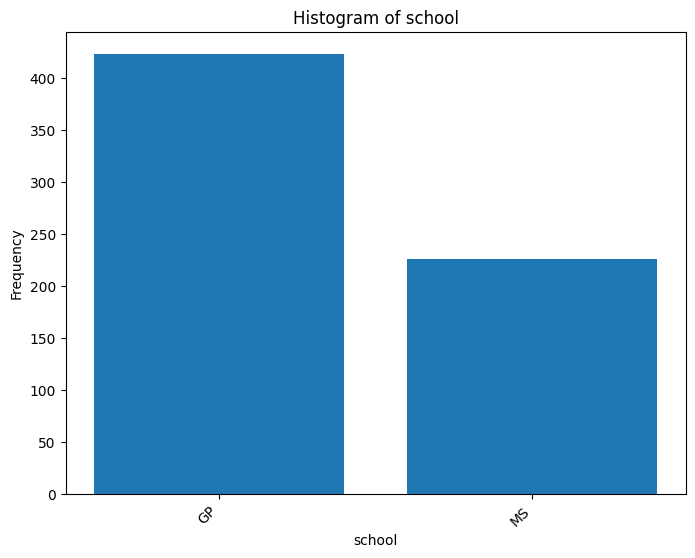

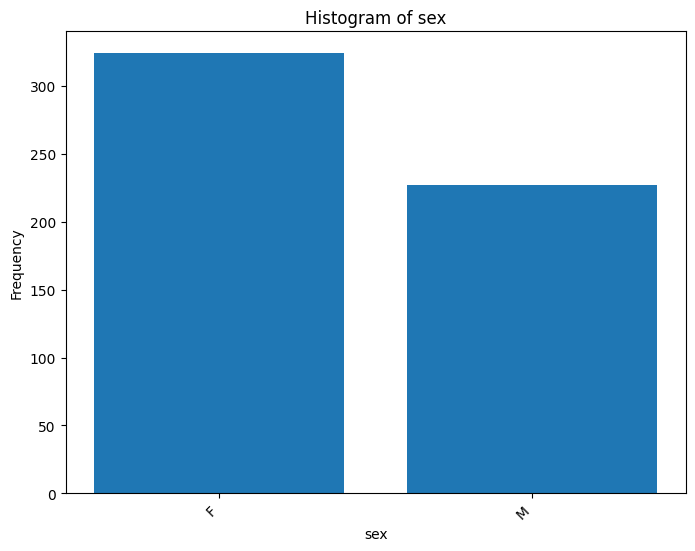

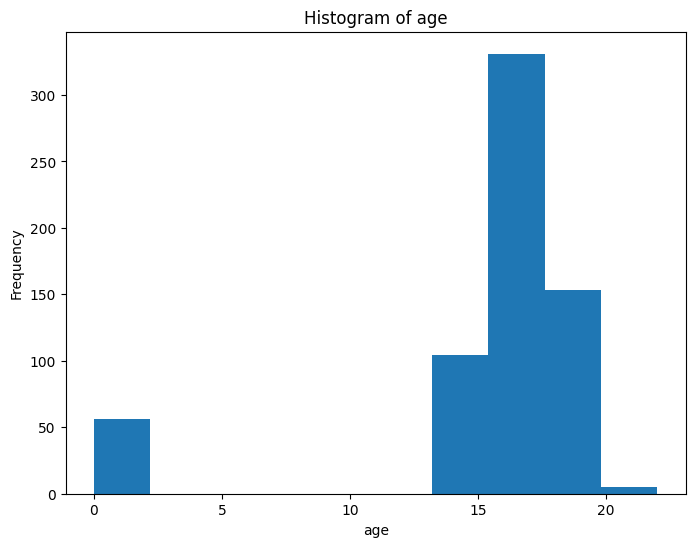

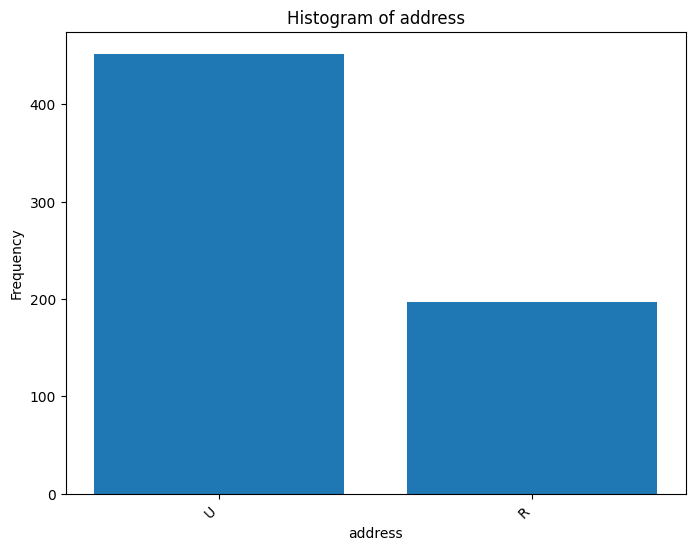

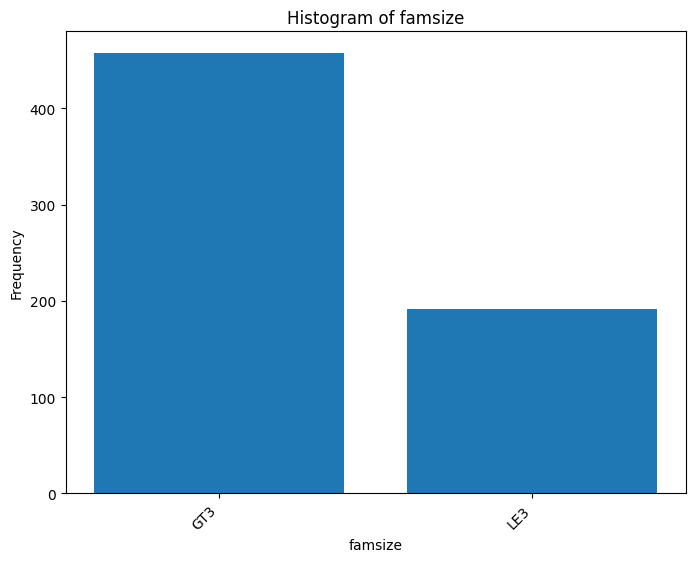

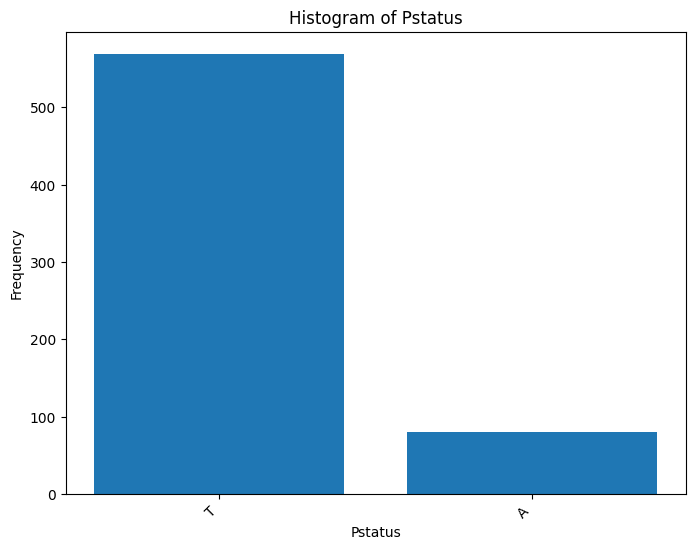

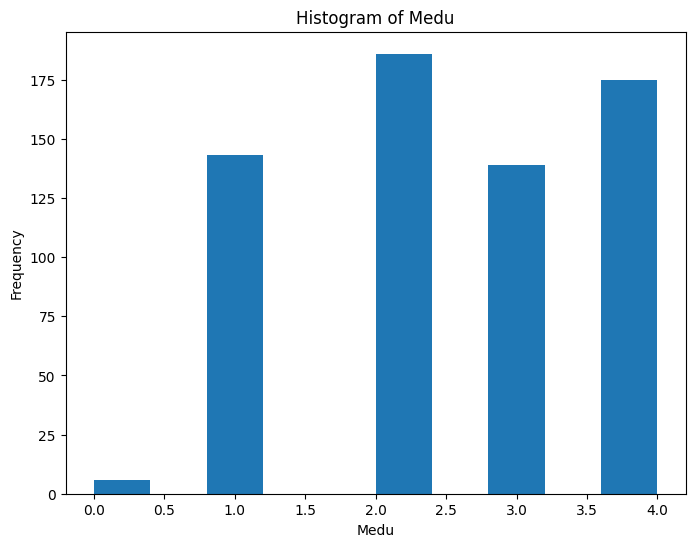

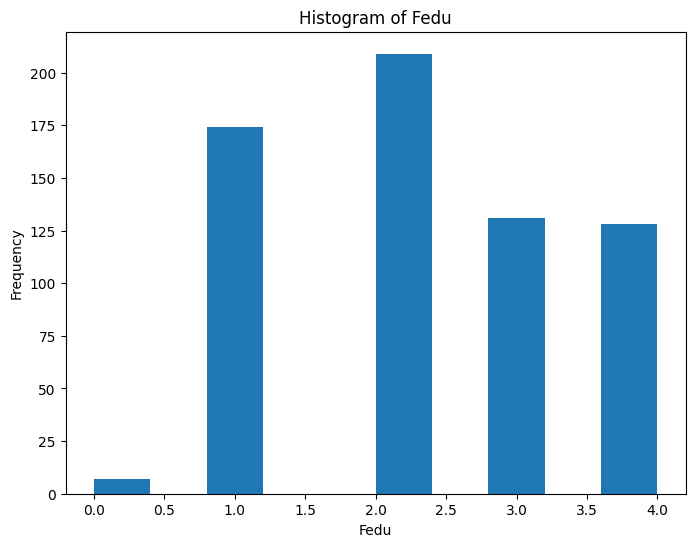

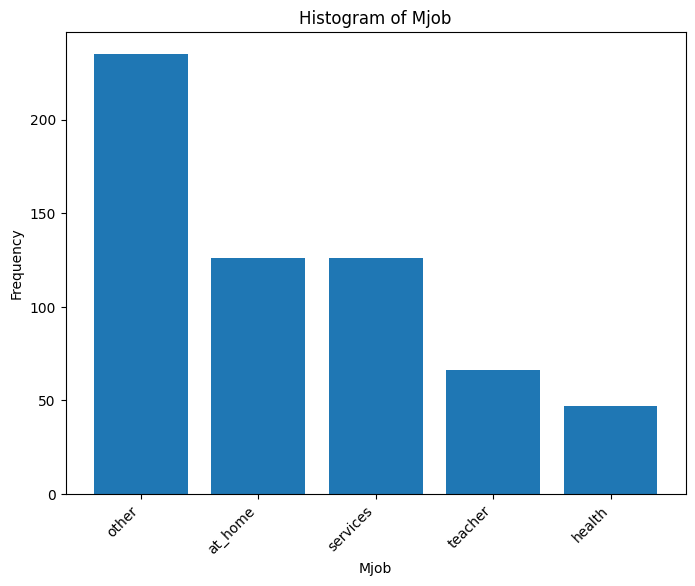

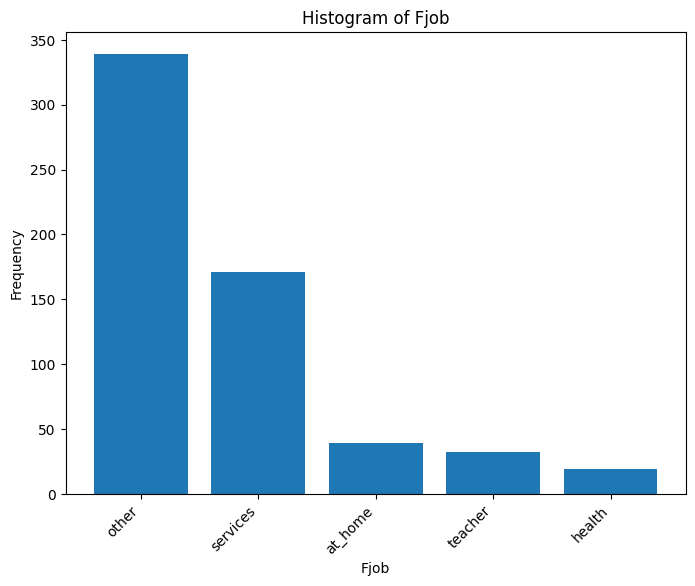

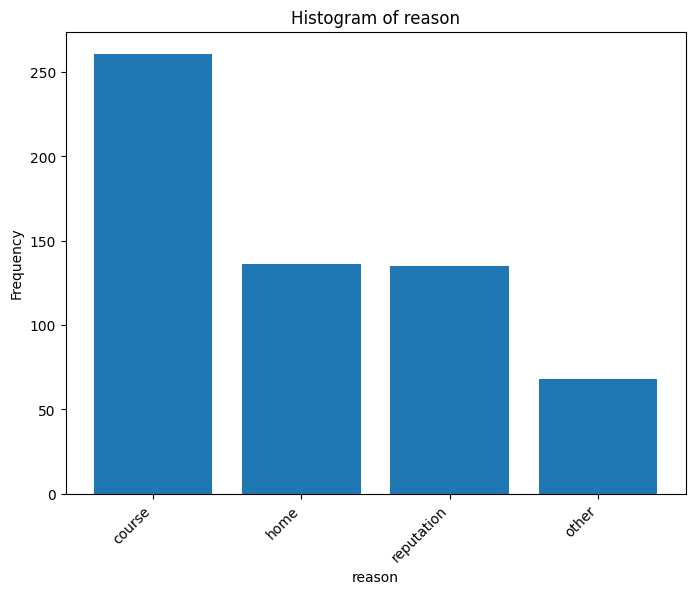

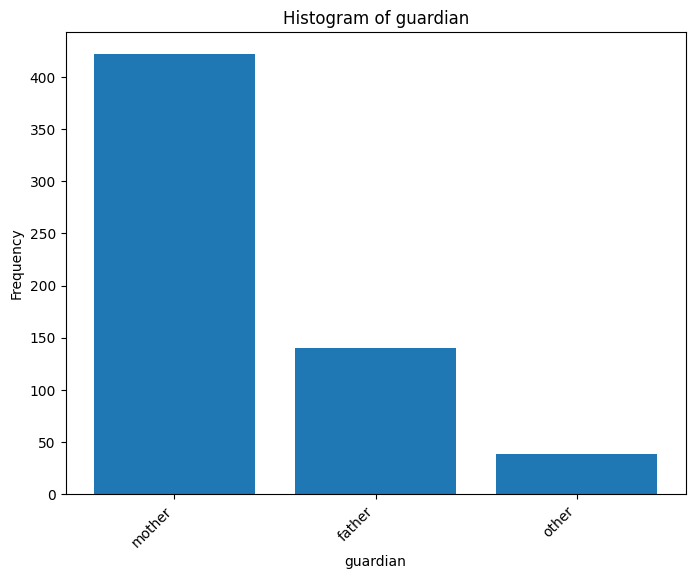

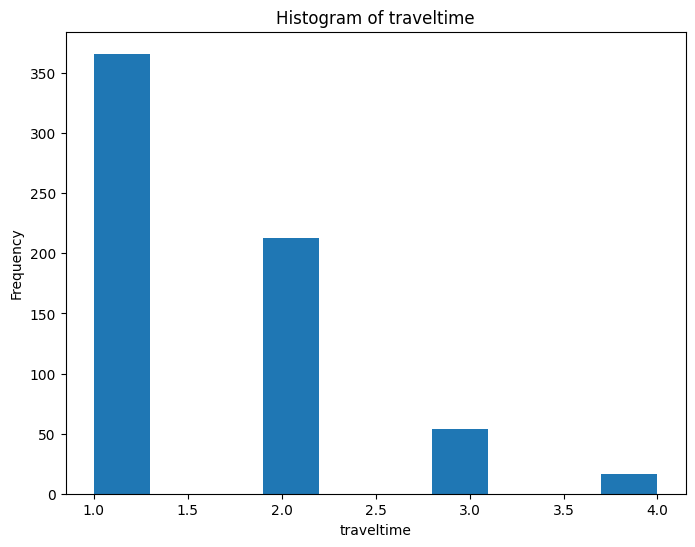

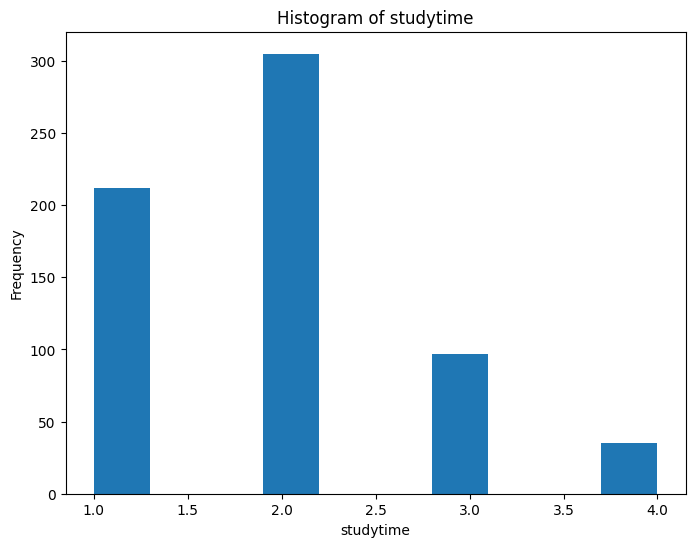

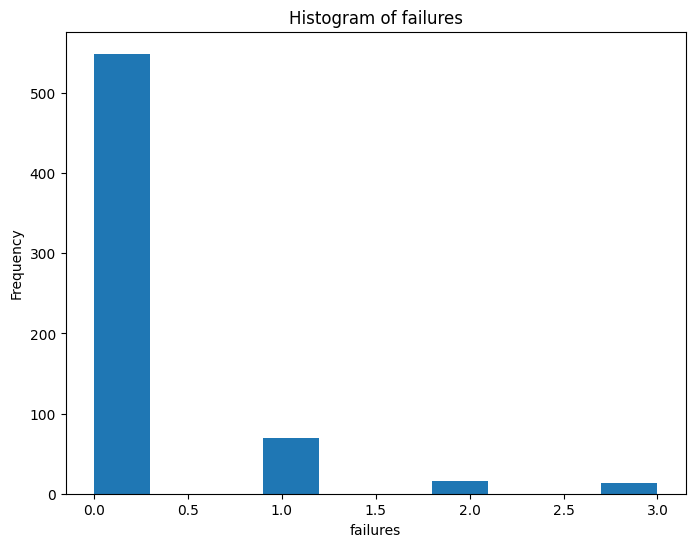

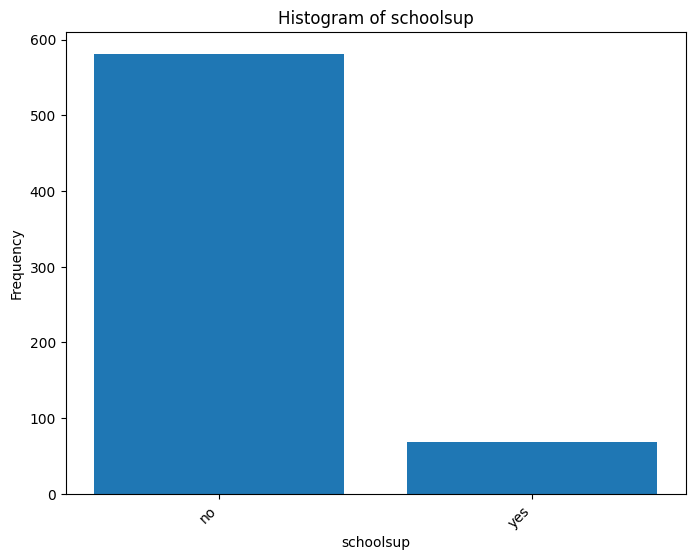

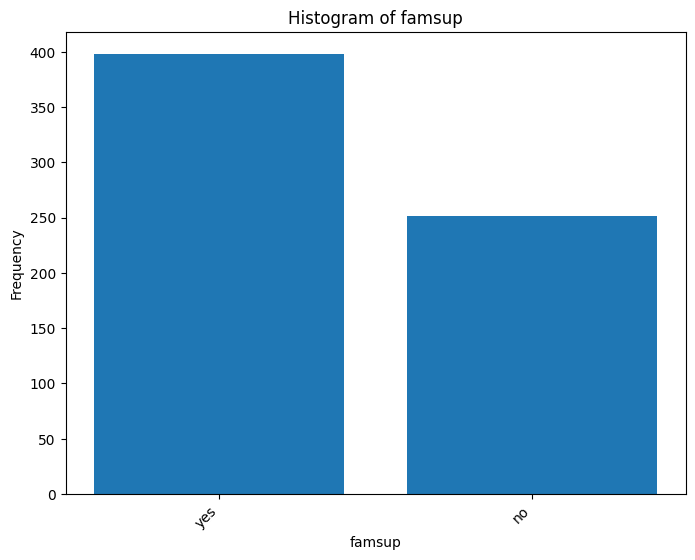

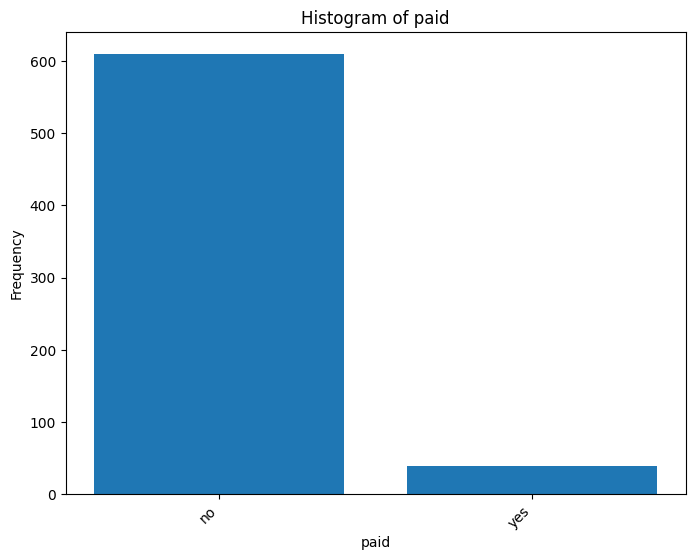

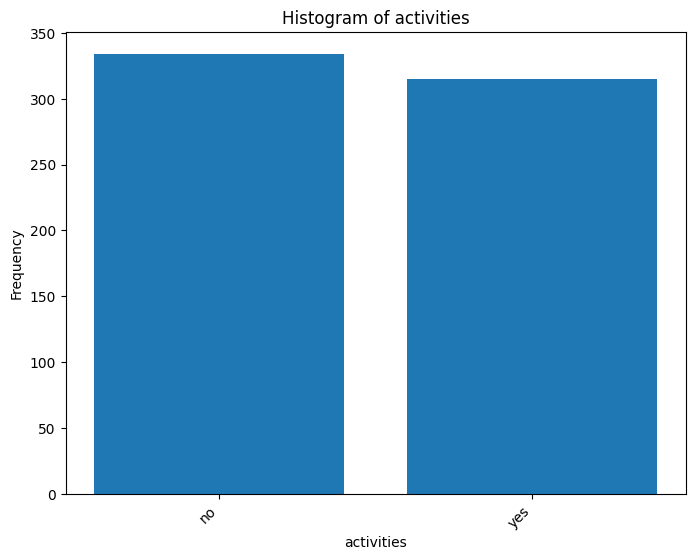

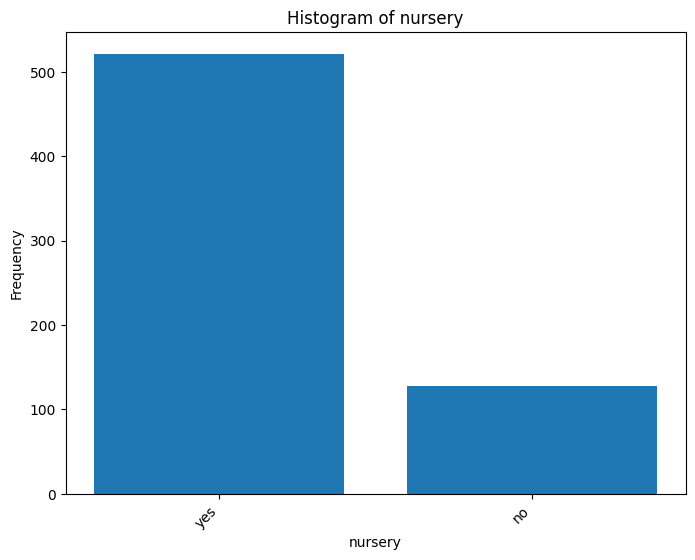

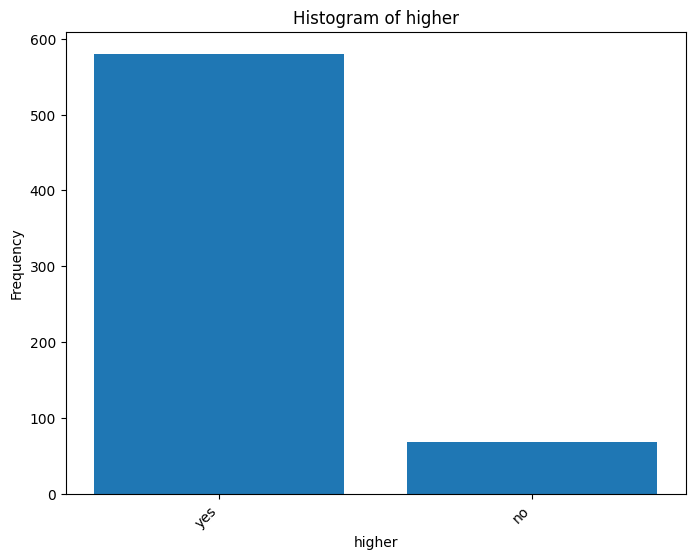

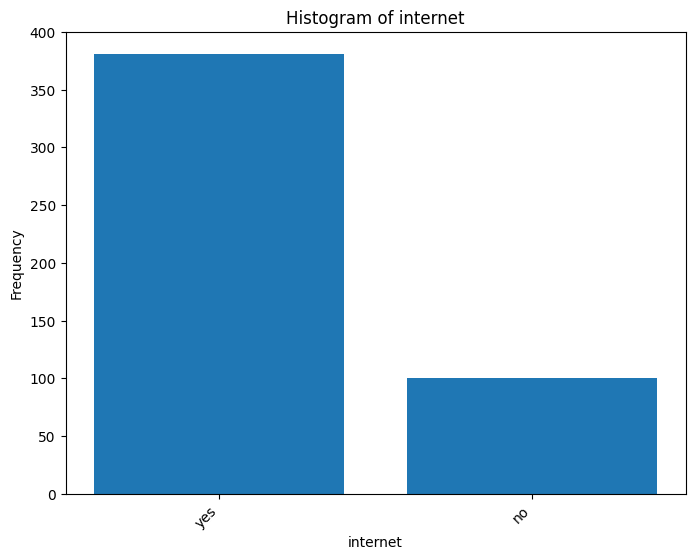

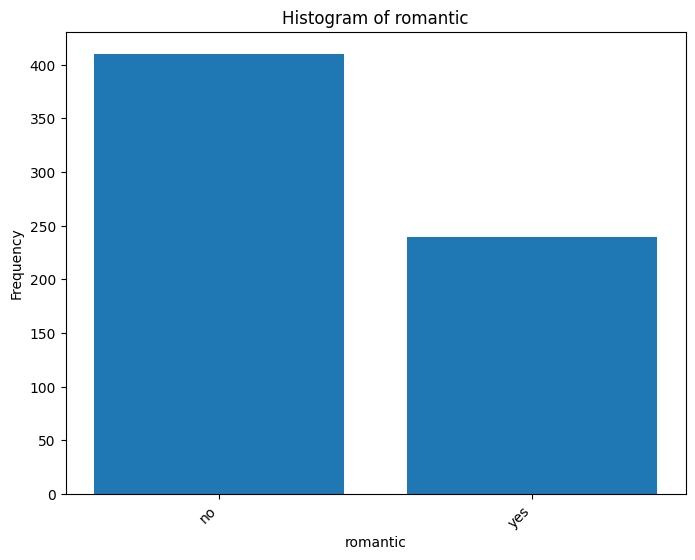

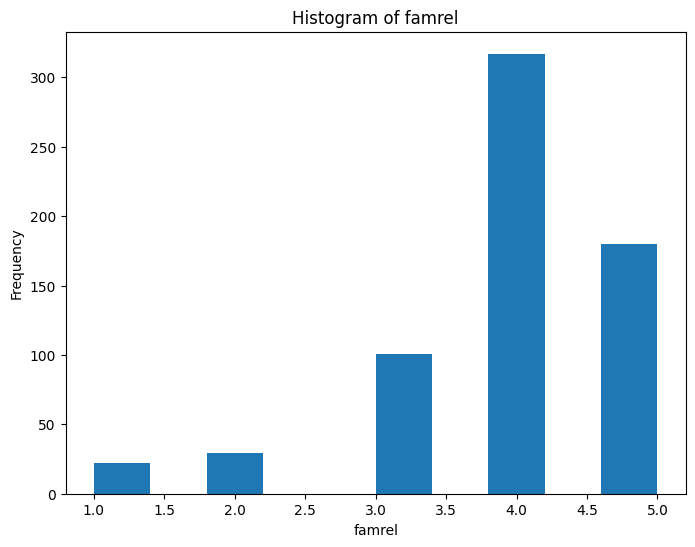

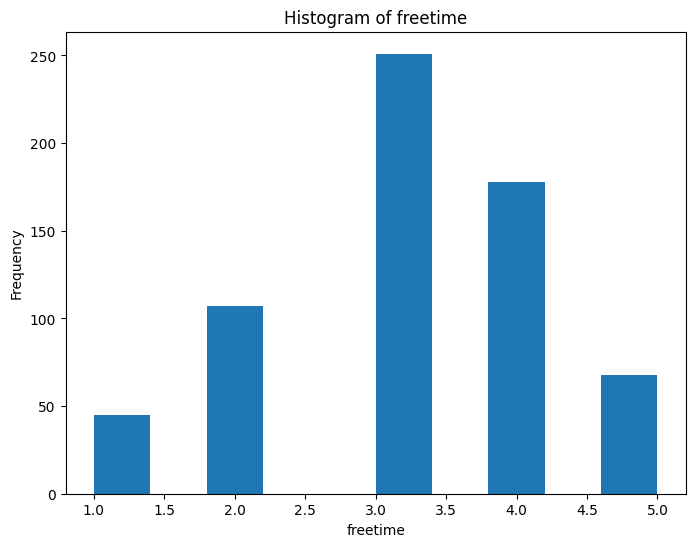

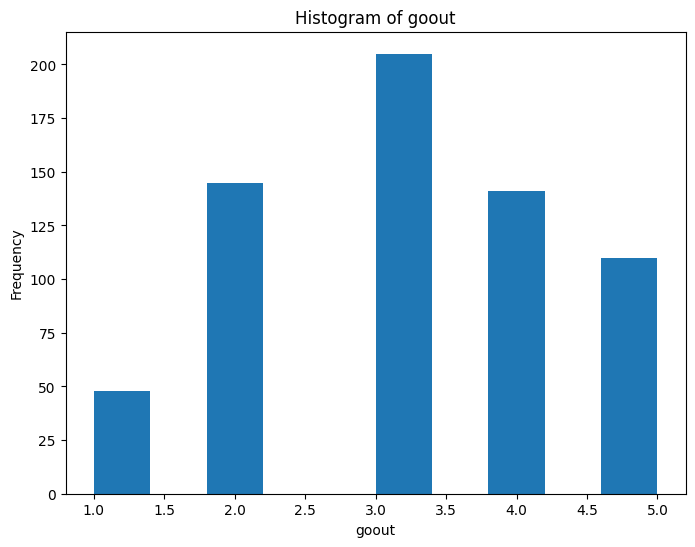

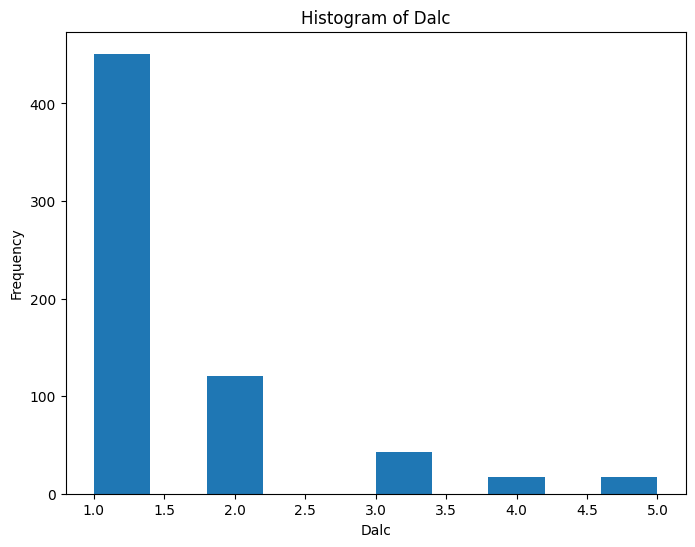

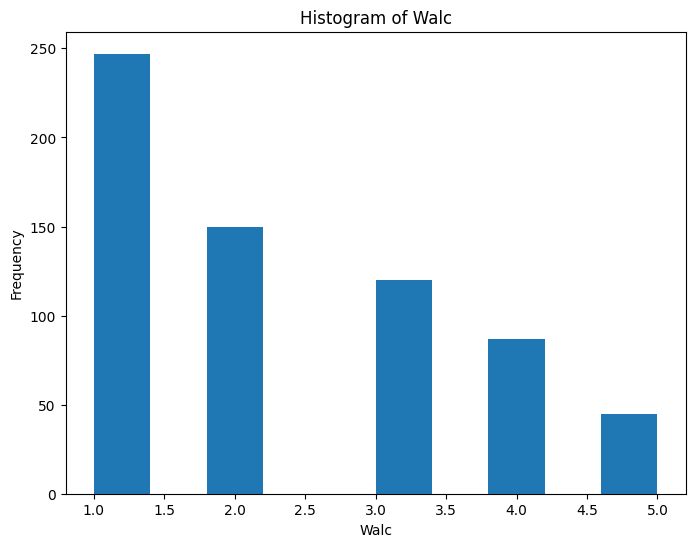

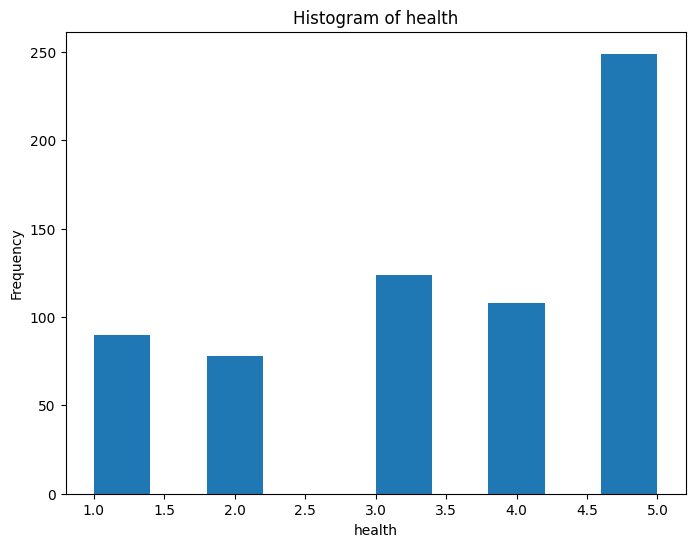

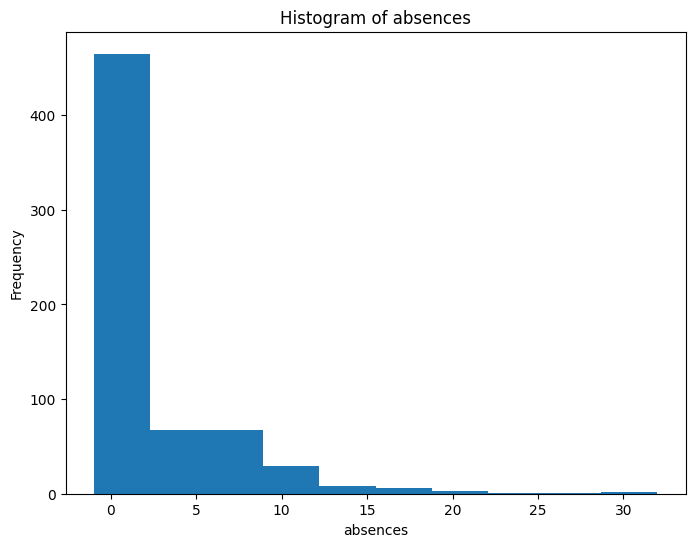

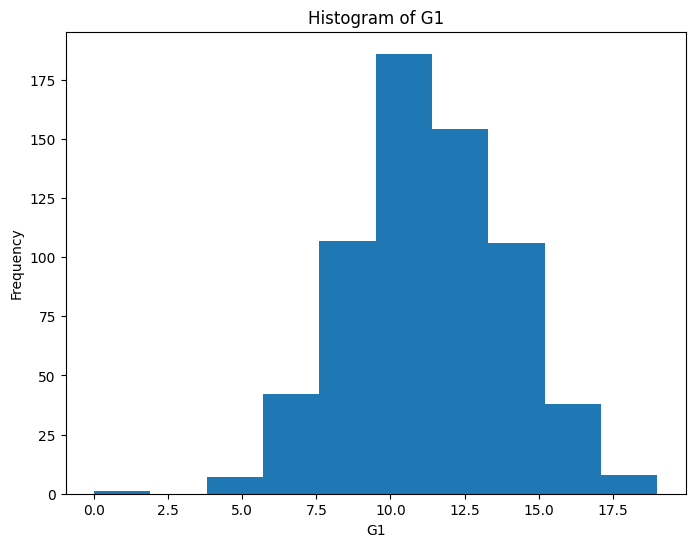

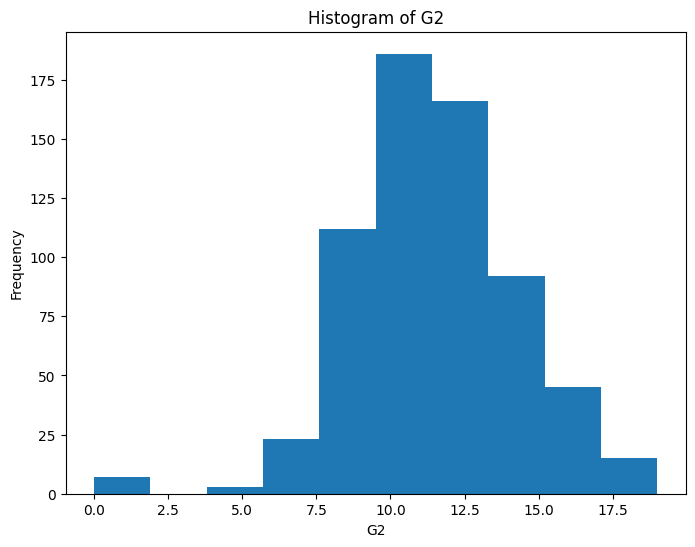

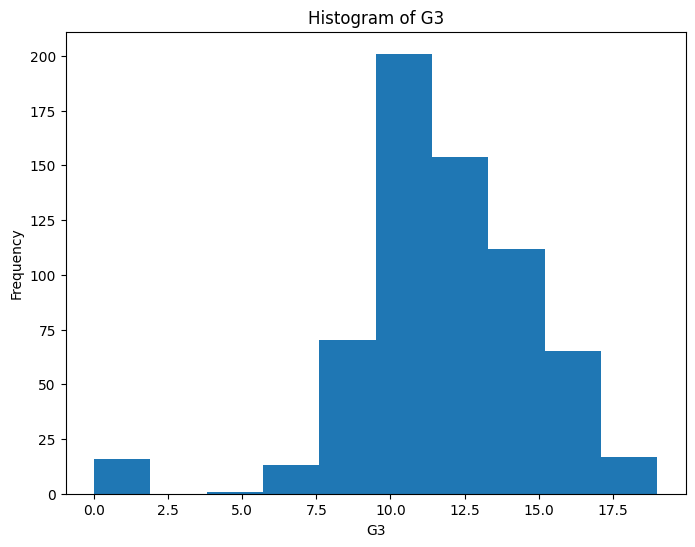

In [12]:
# Plot histogram to all of the variables
for column in data_DF.columns:
    # Create a histogram for the current column
    plt.figure(figsize=(8, 6))

    # Check if the column contains numeric data
    if np.issubdtype(data_DF[column].dtype, np.number):
        plt.hist(data_DF[column], bins=10)  # Adjust the number of bins as needed
    else:
        # Handle non-numeric data
        value_counts = data_DF[column].value_counts()
        plt.bar(value_counts.index, value_counts.values)
        plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed

    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

## Boxploty
Vykreslení závislosti jednotlivých proměnných a skóre.

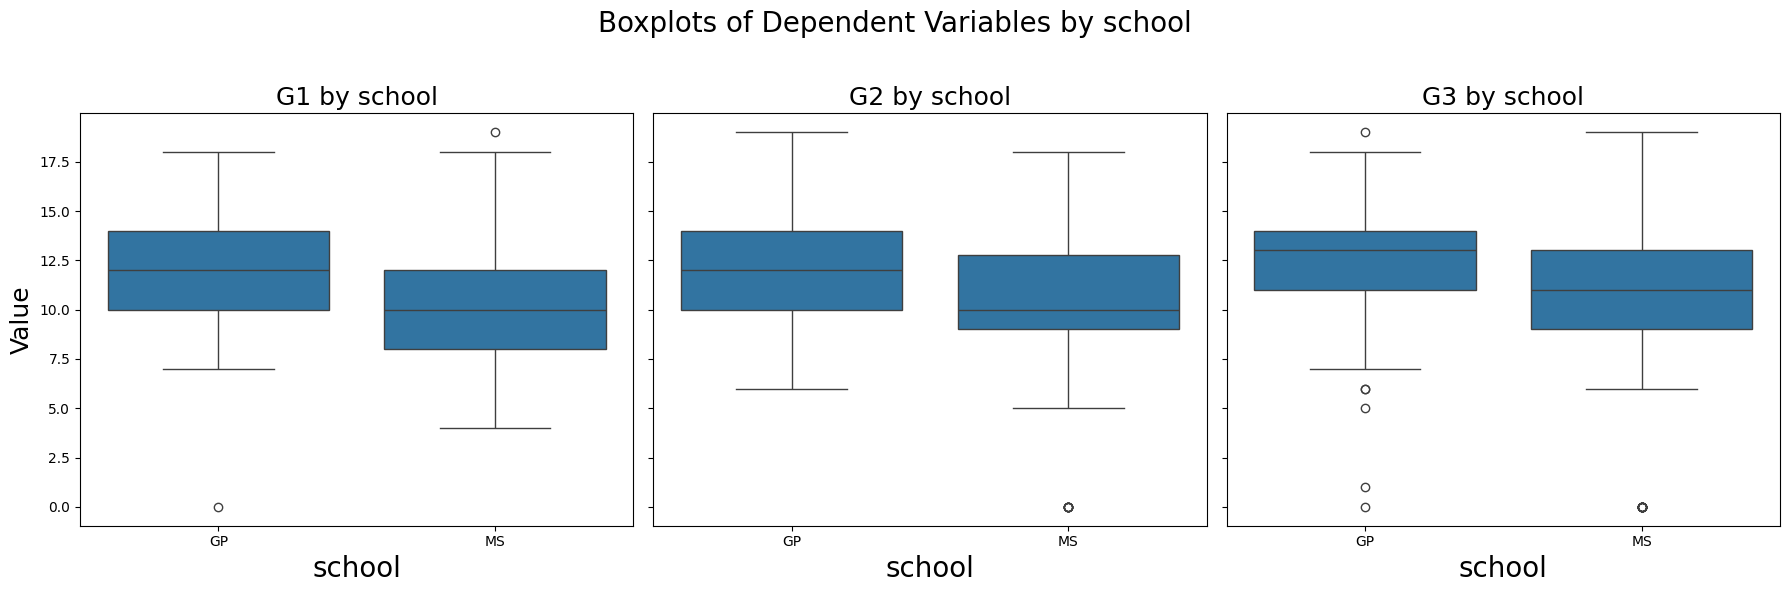

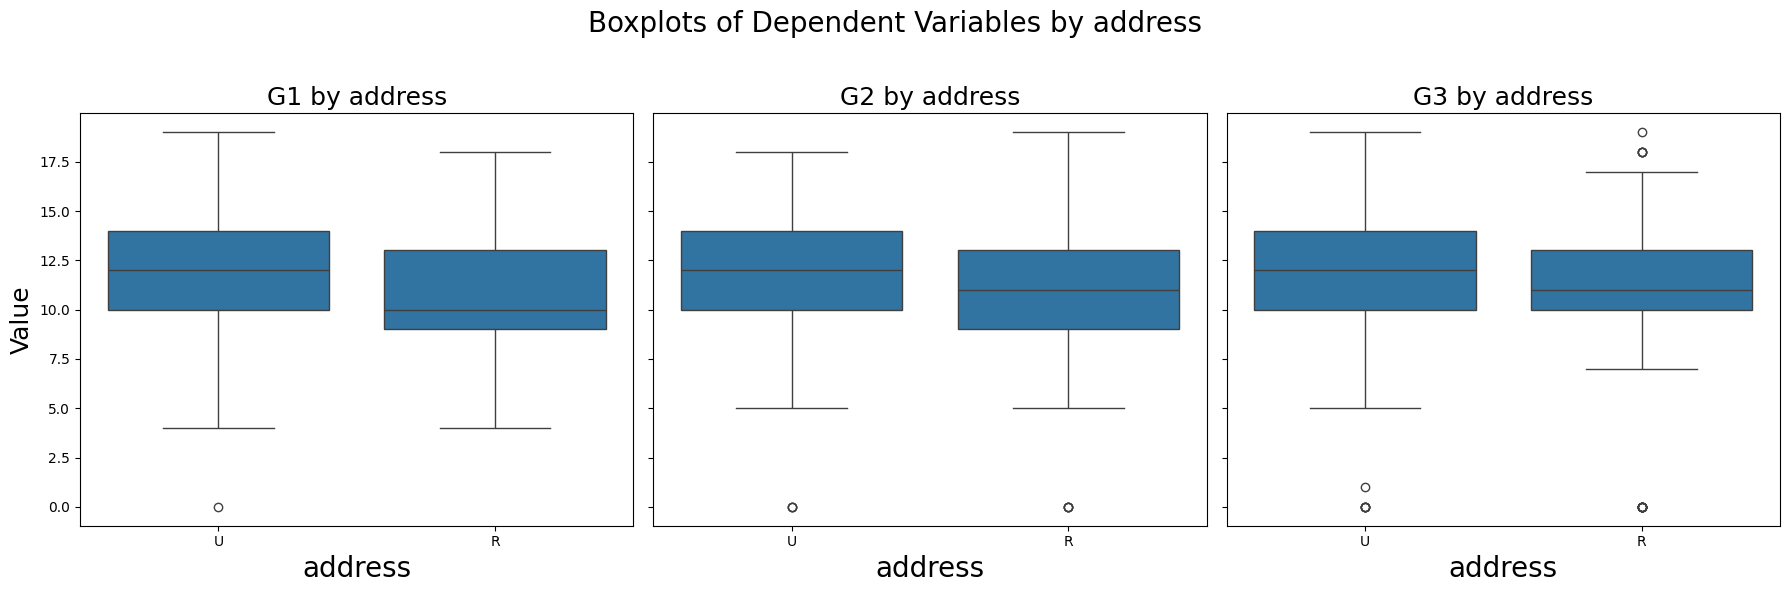

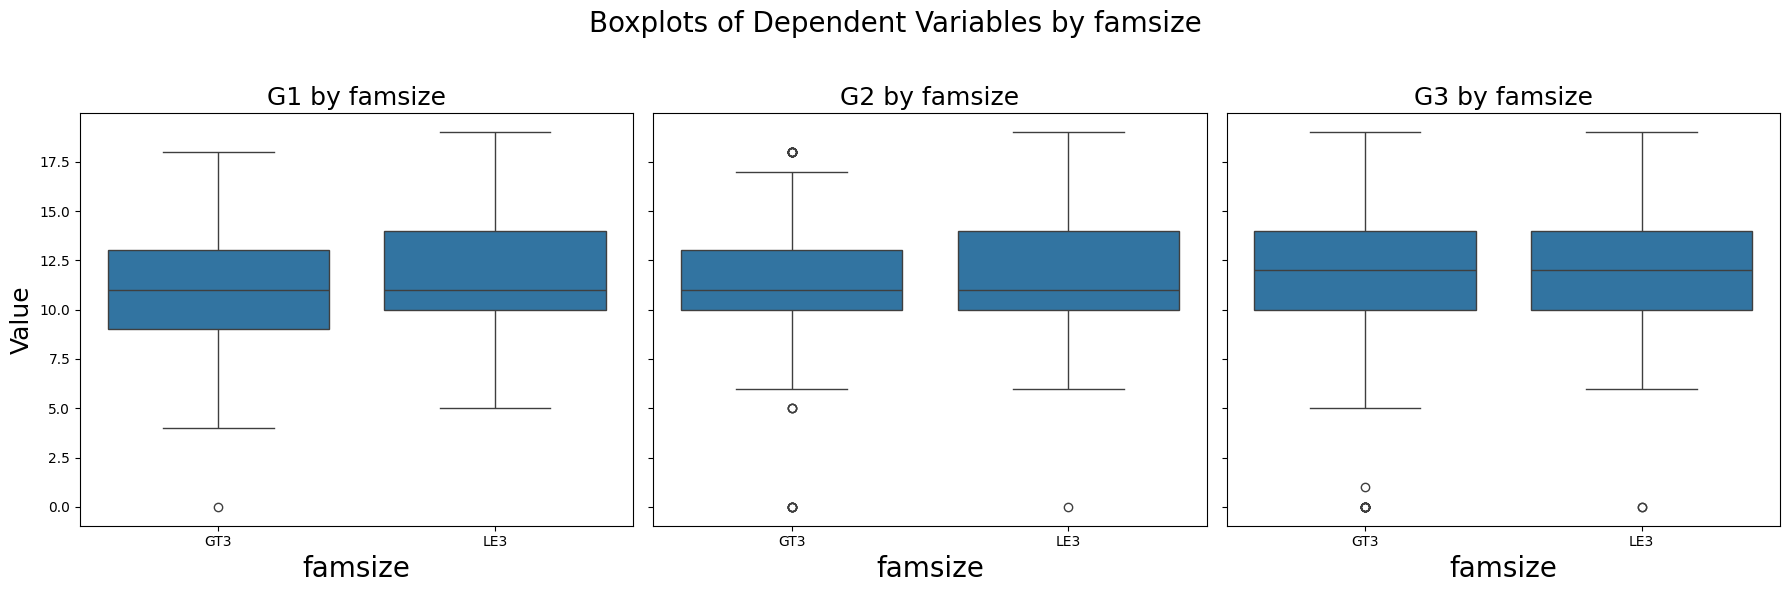

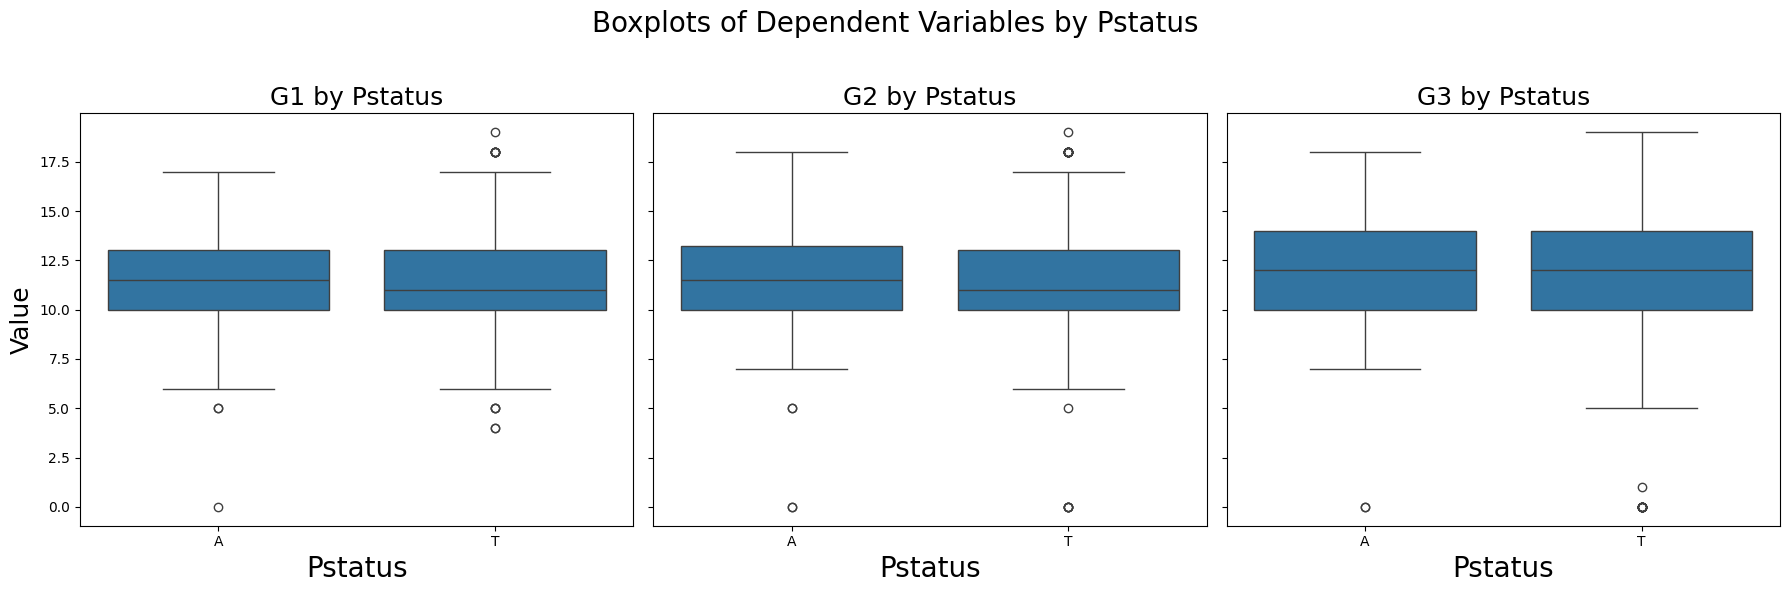

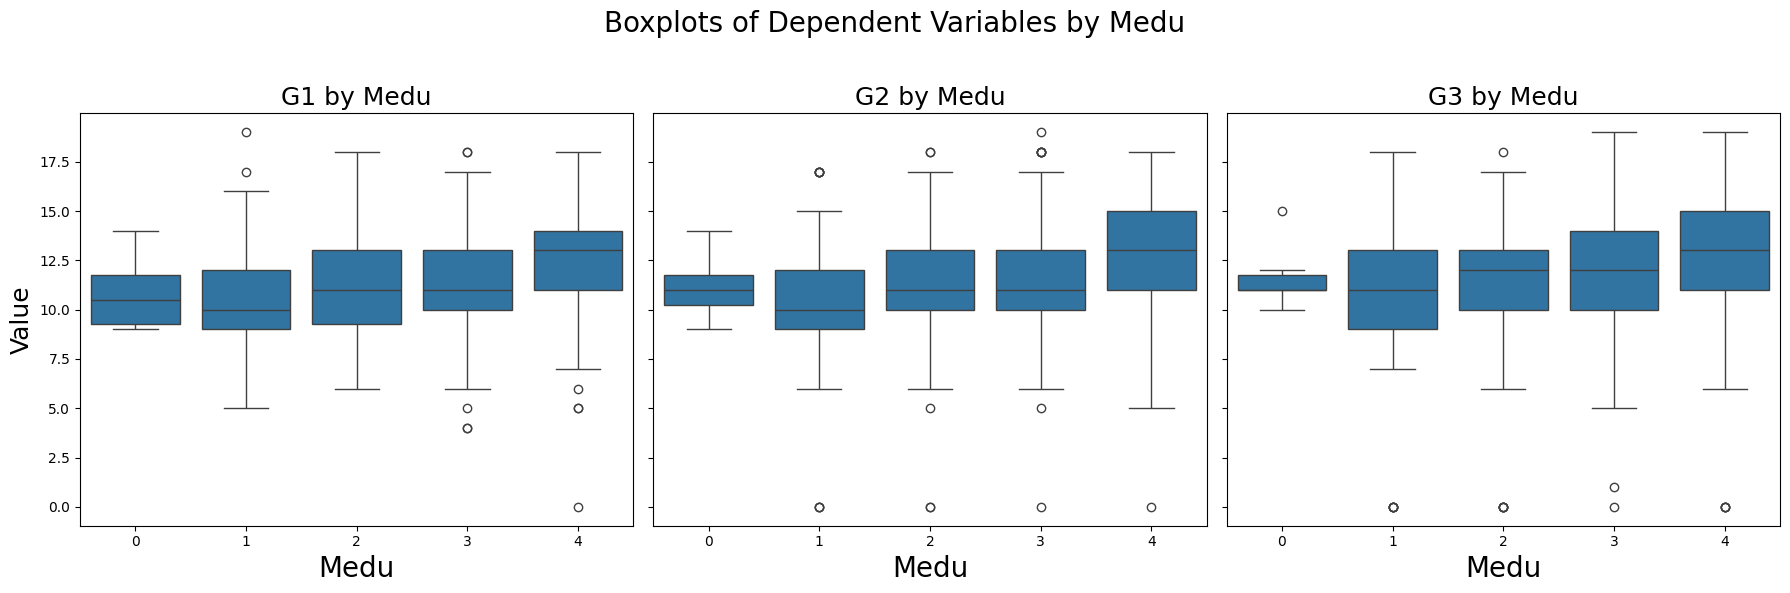

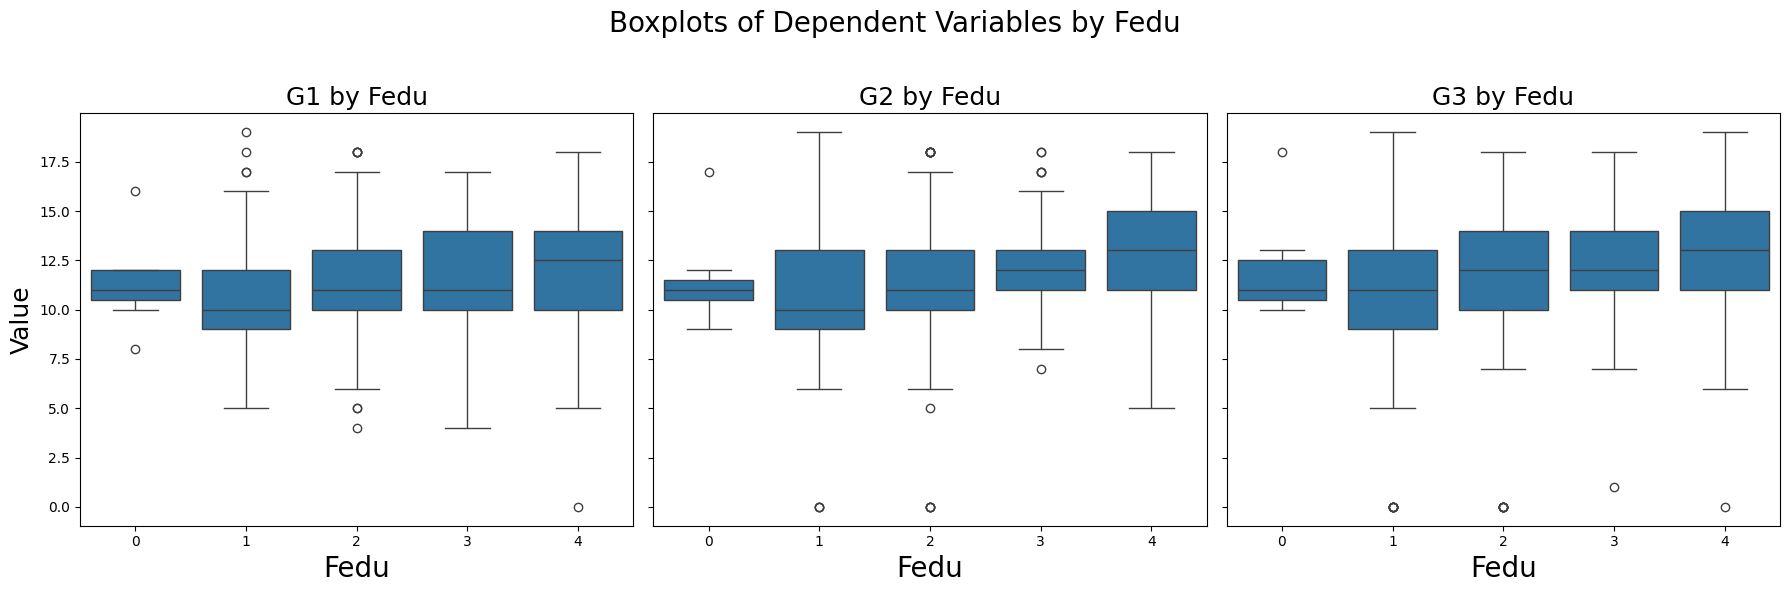

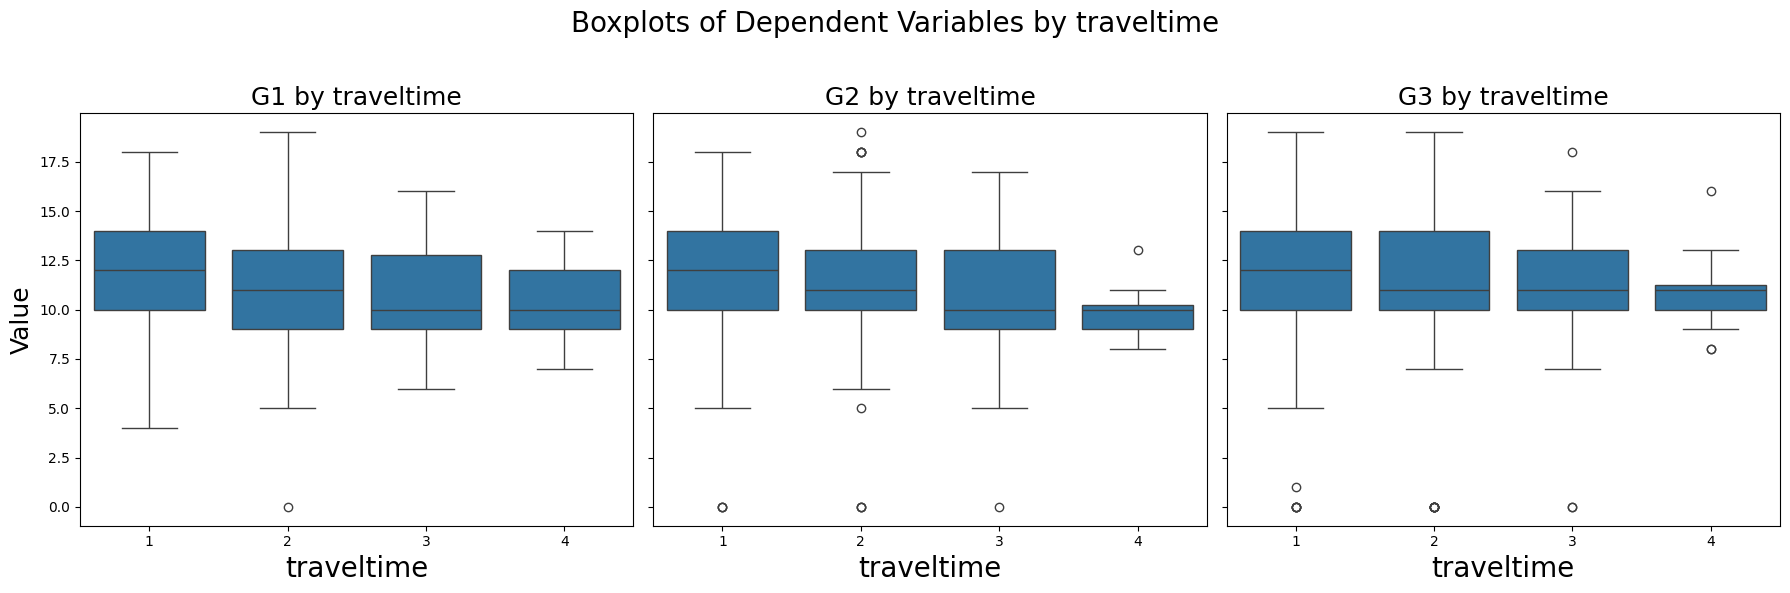

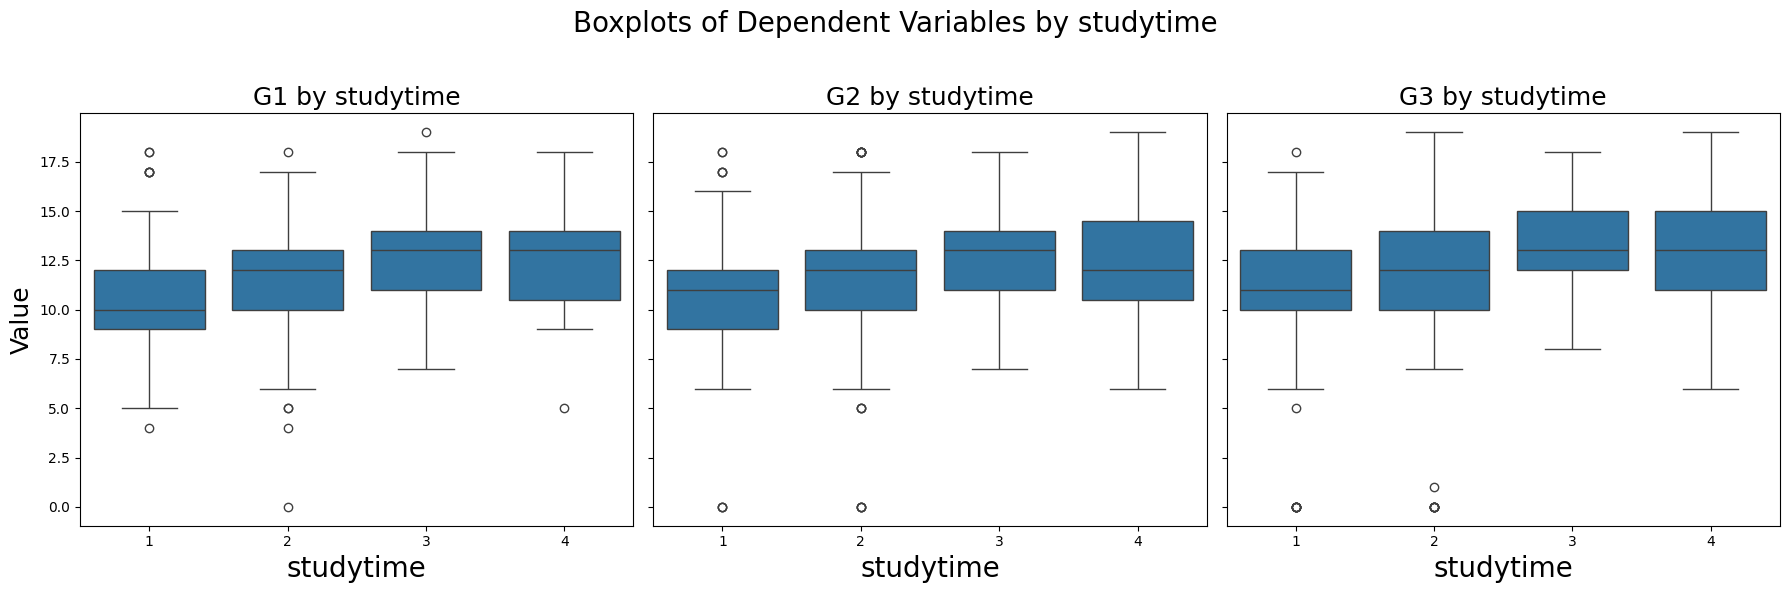

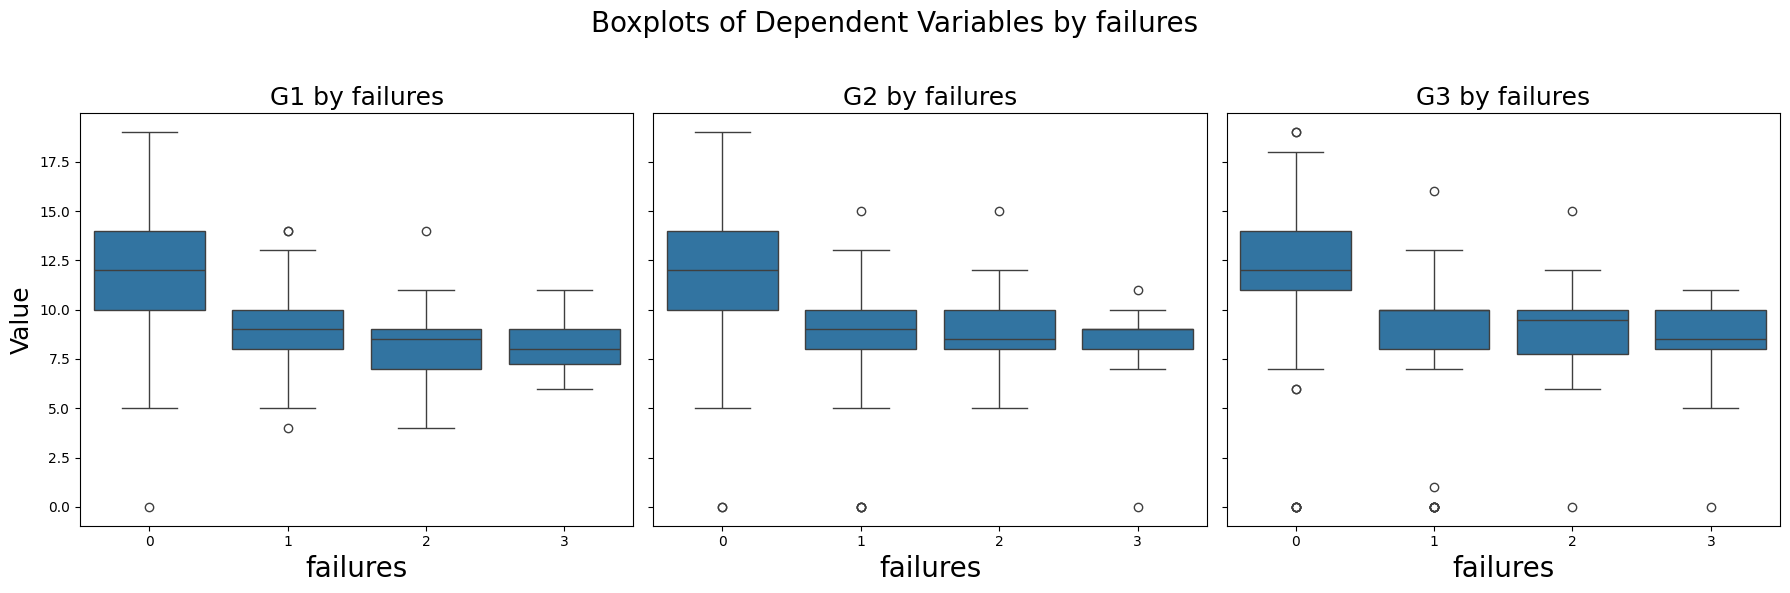

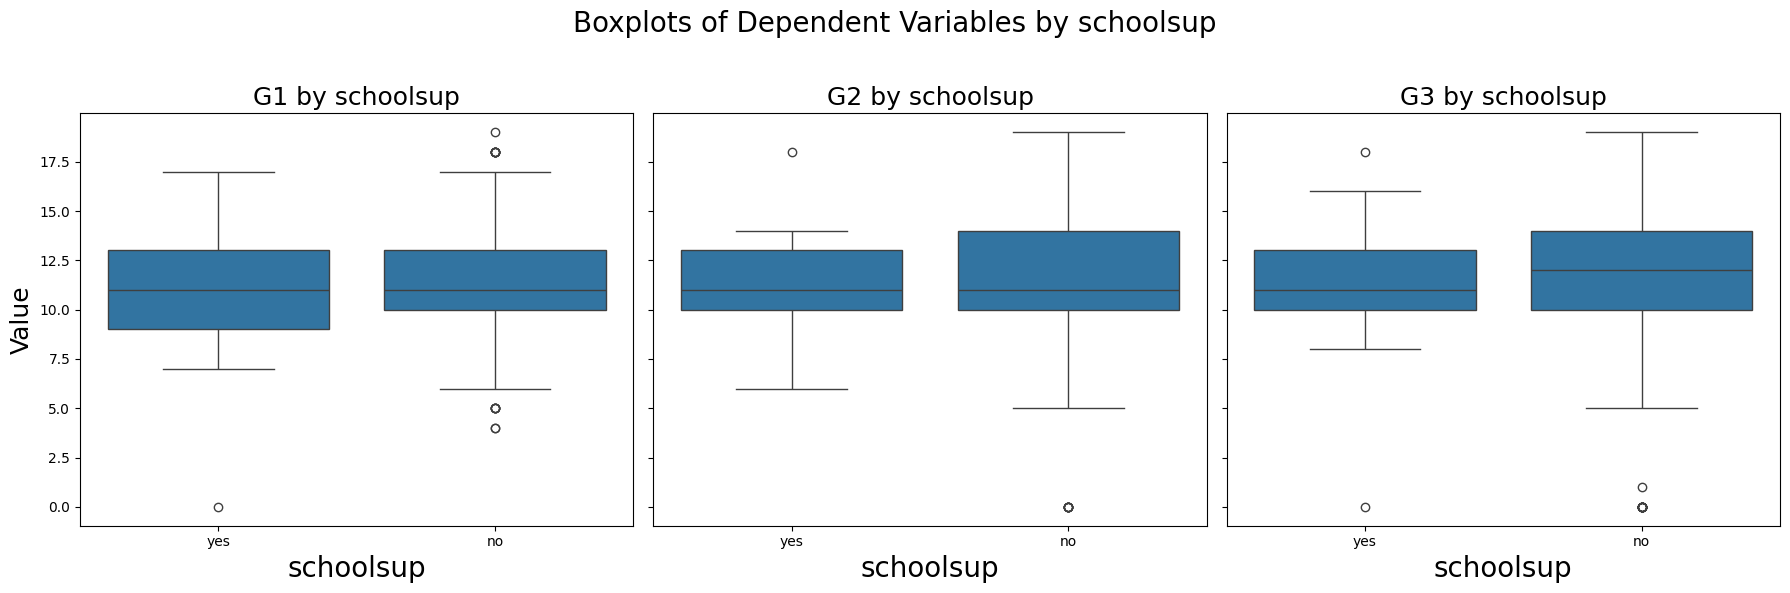

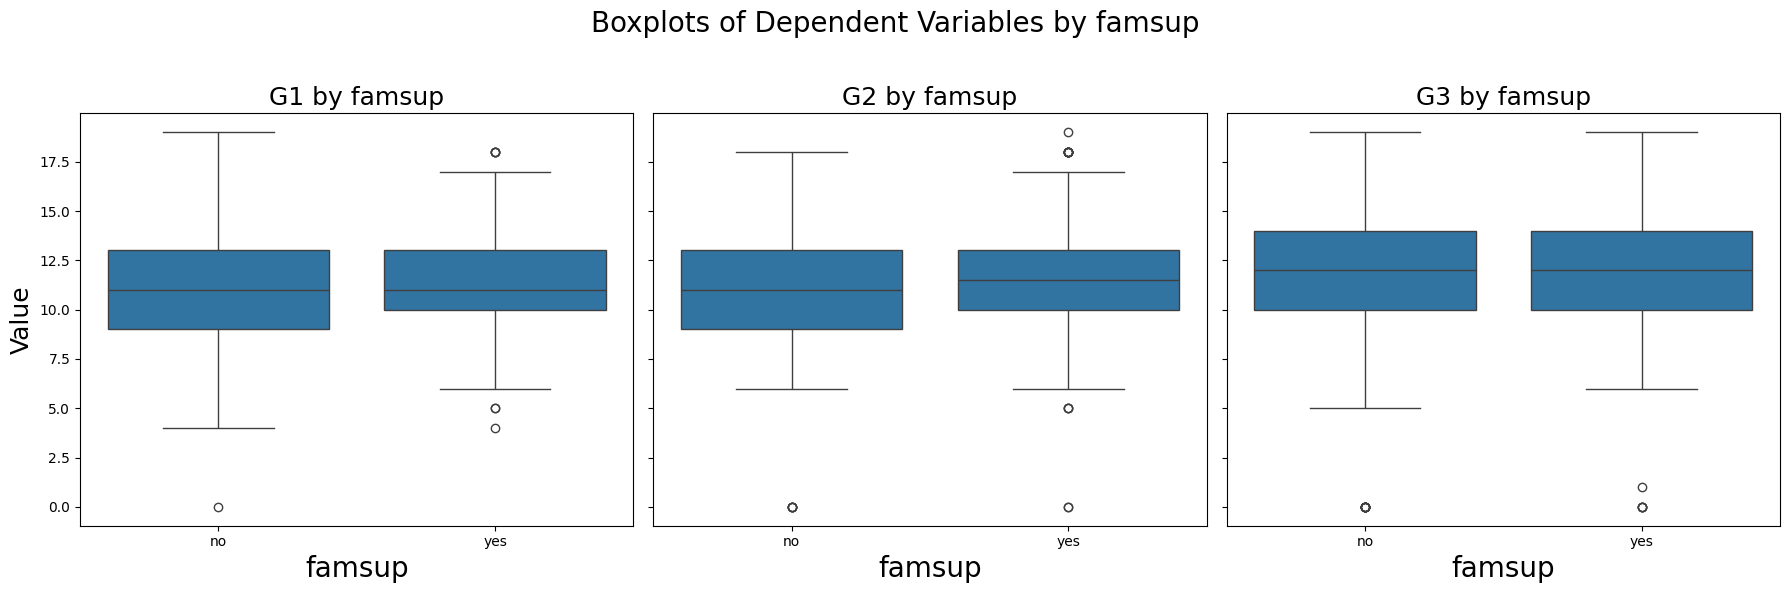

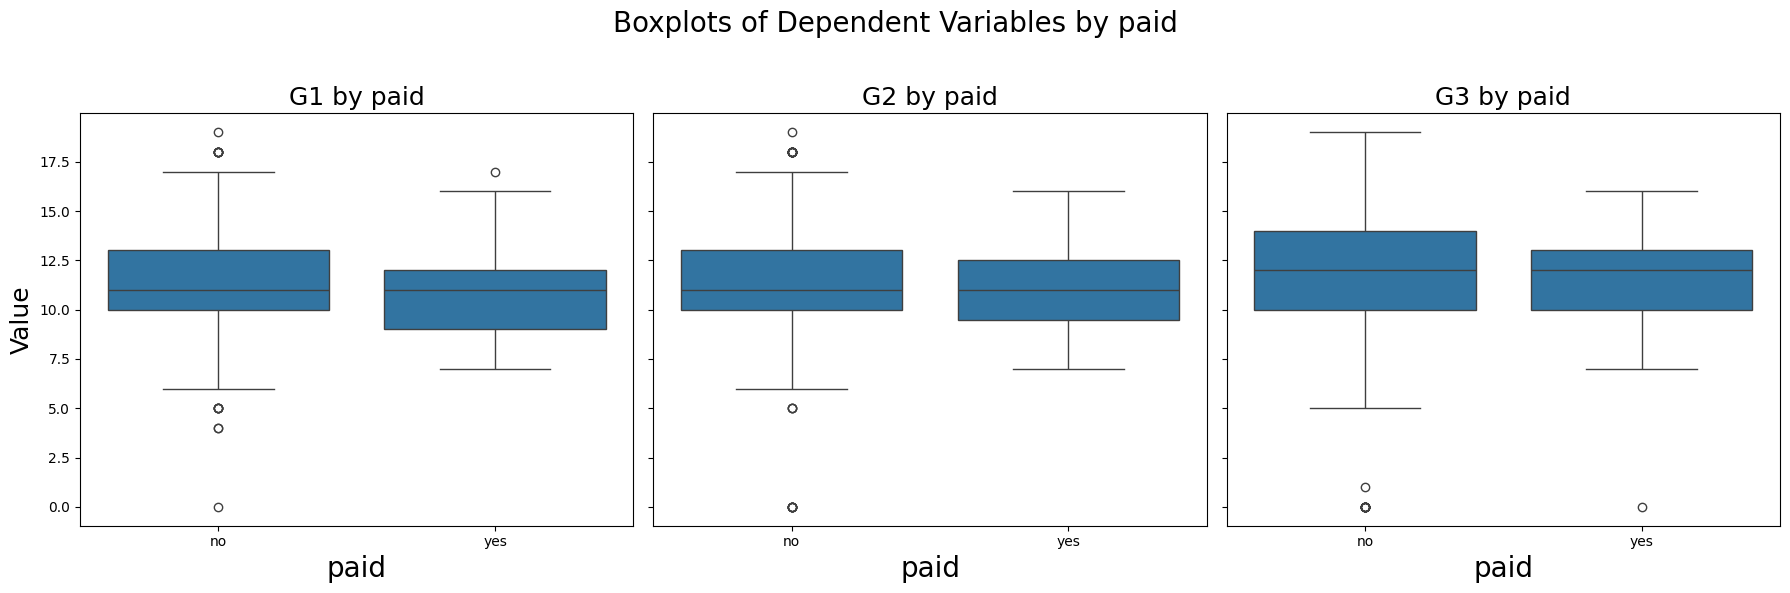

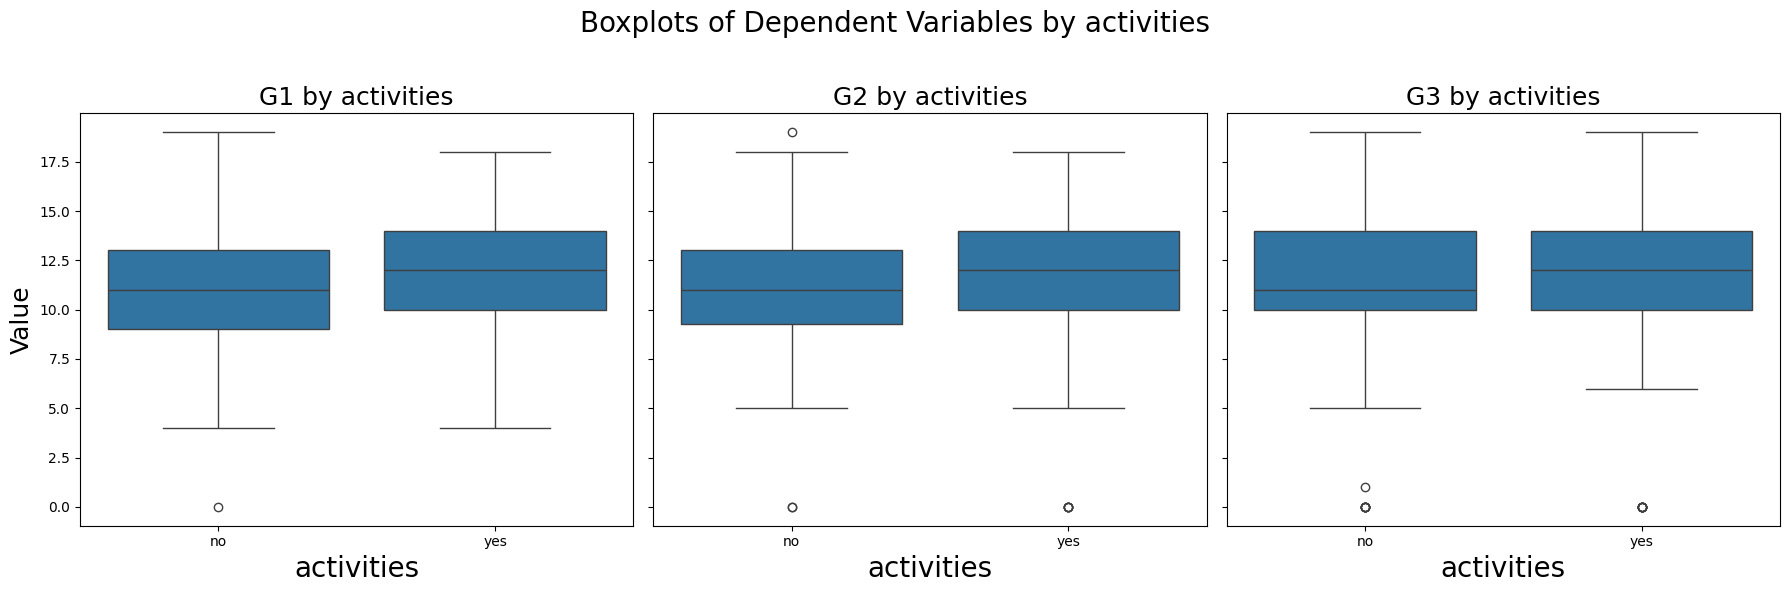

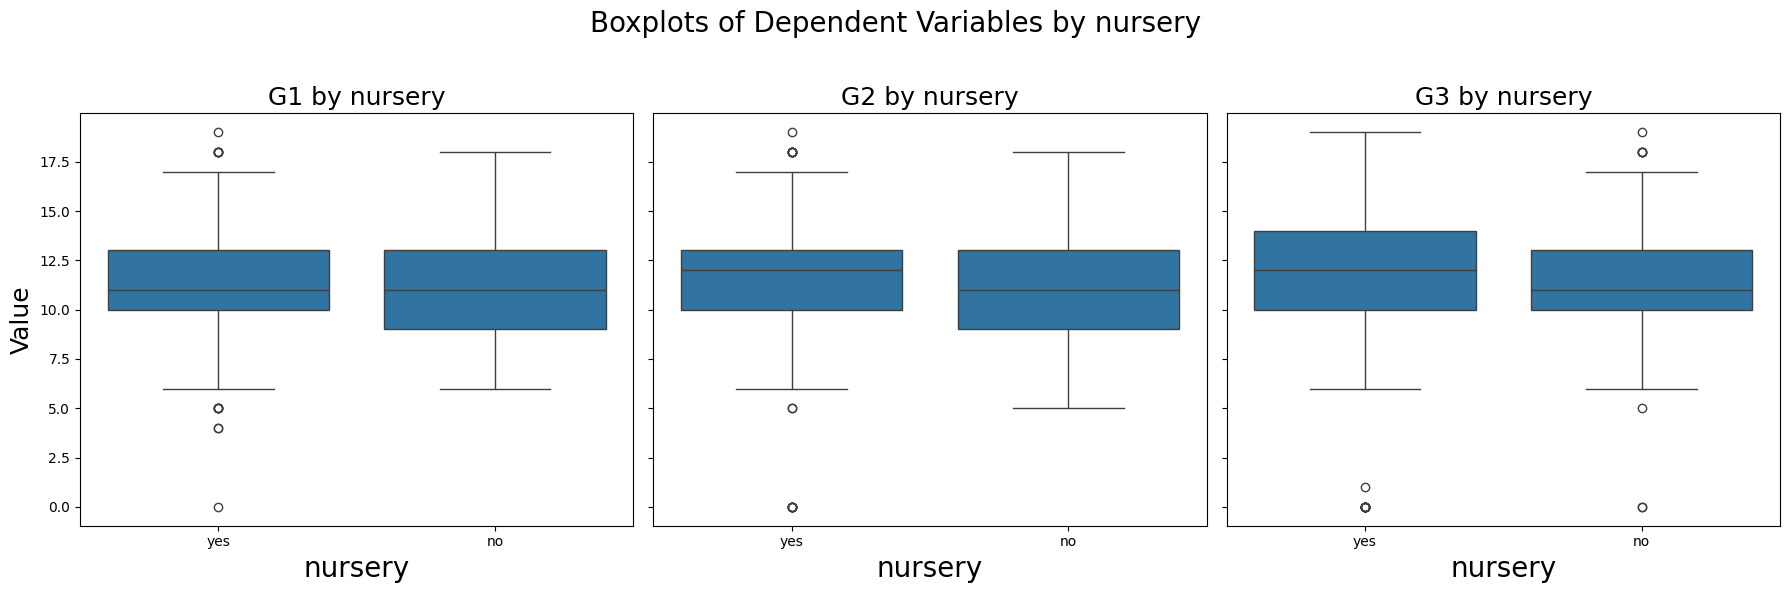

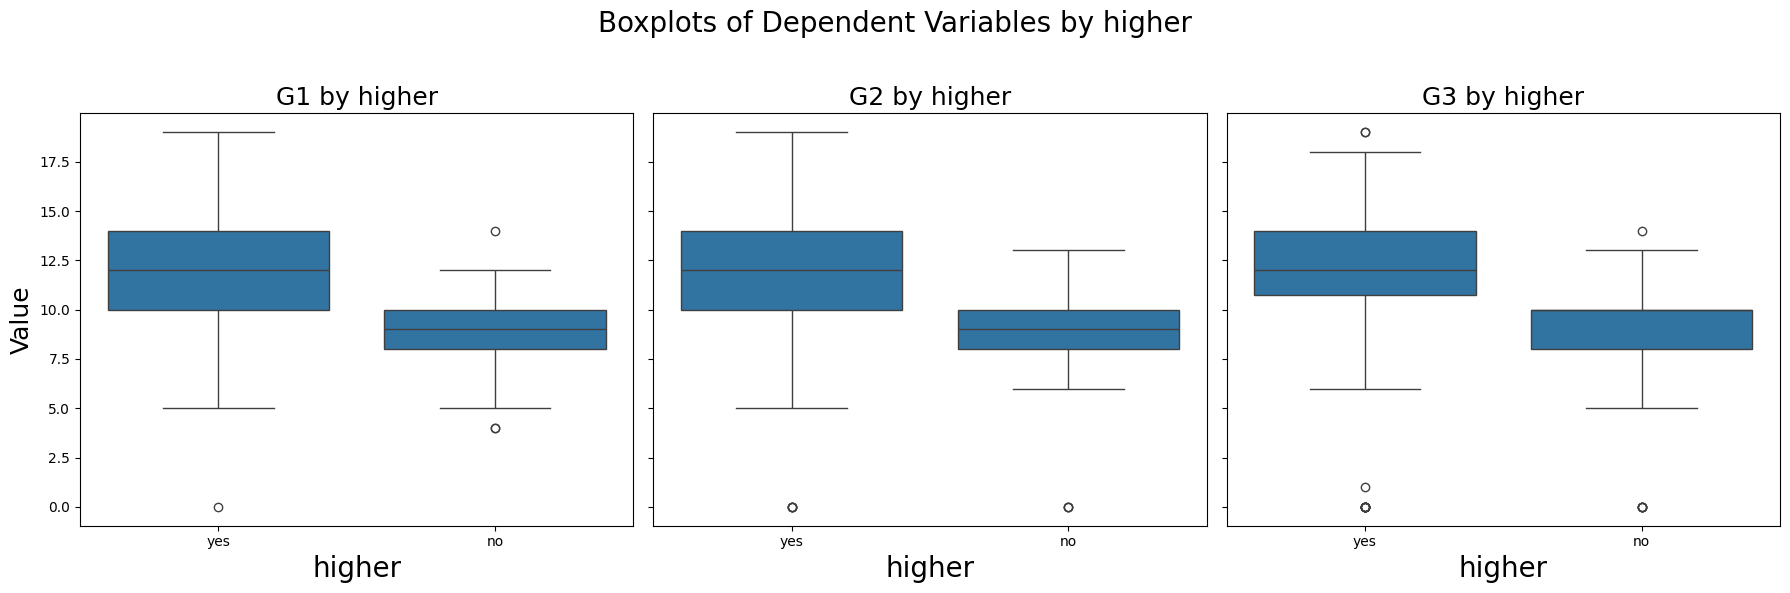

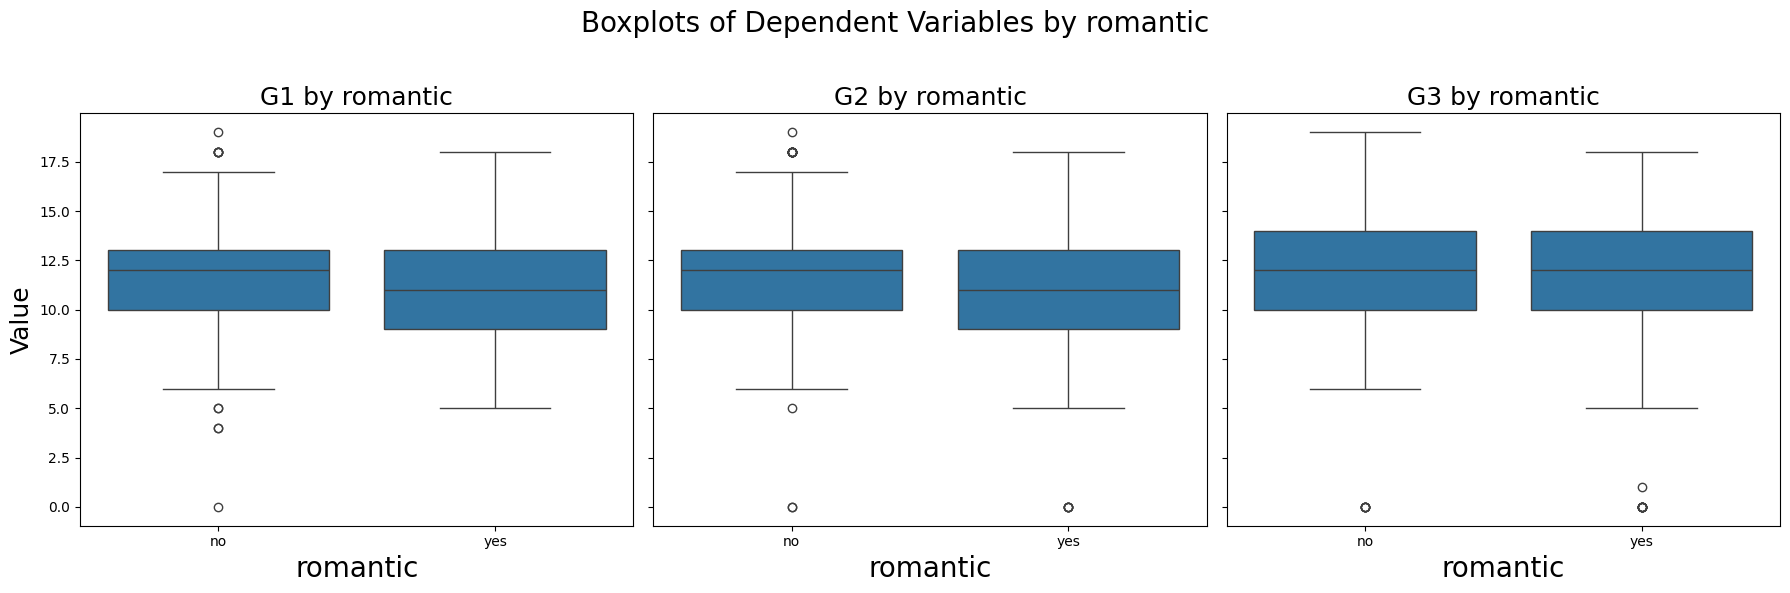

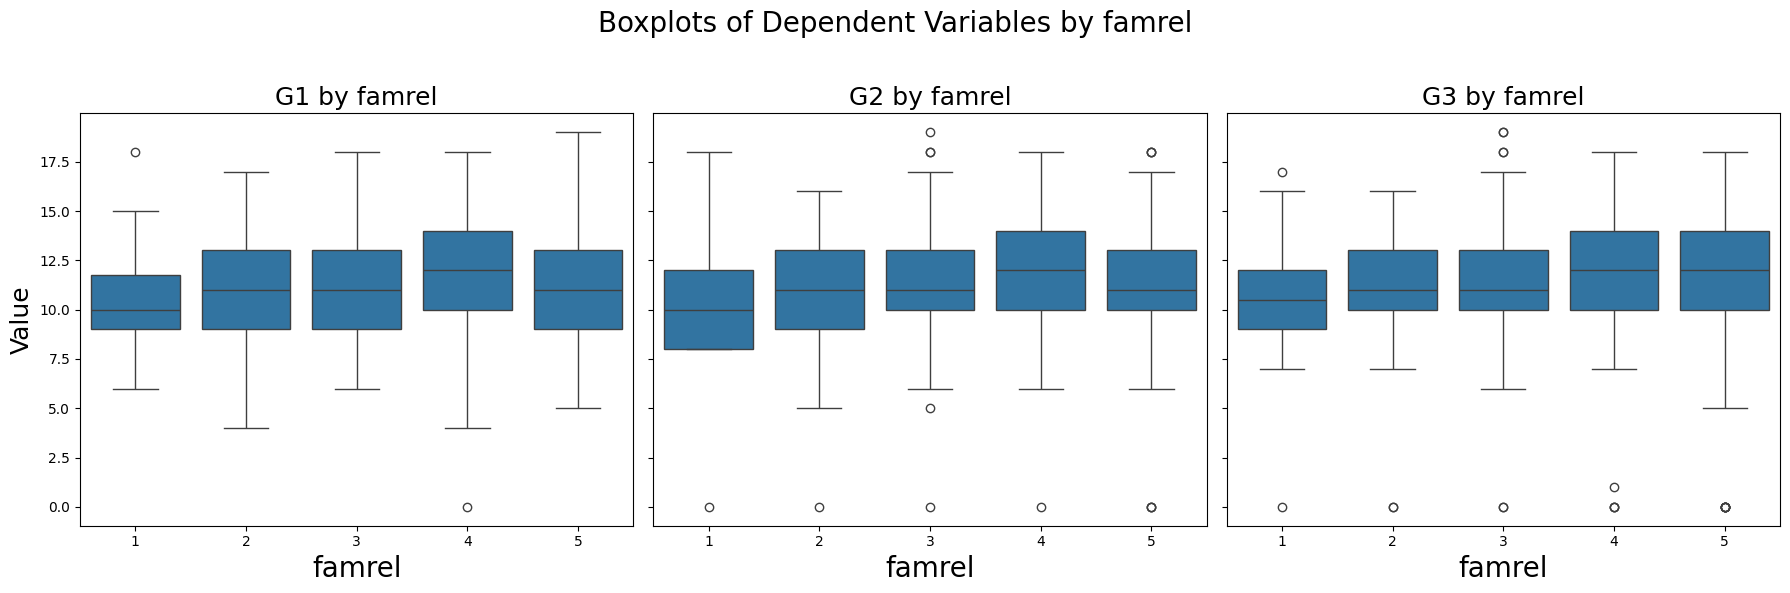

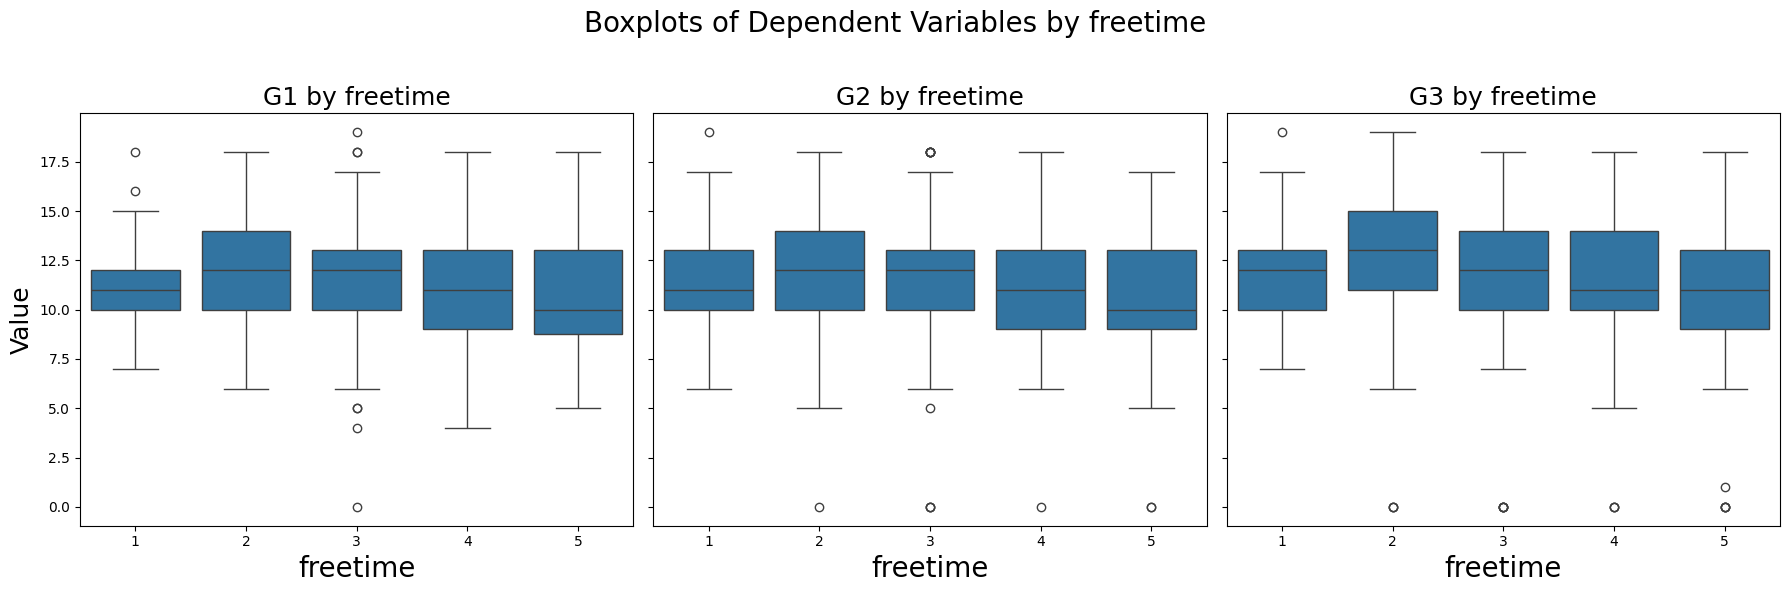

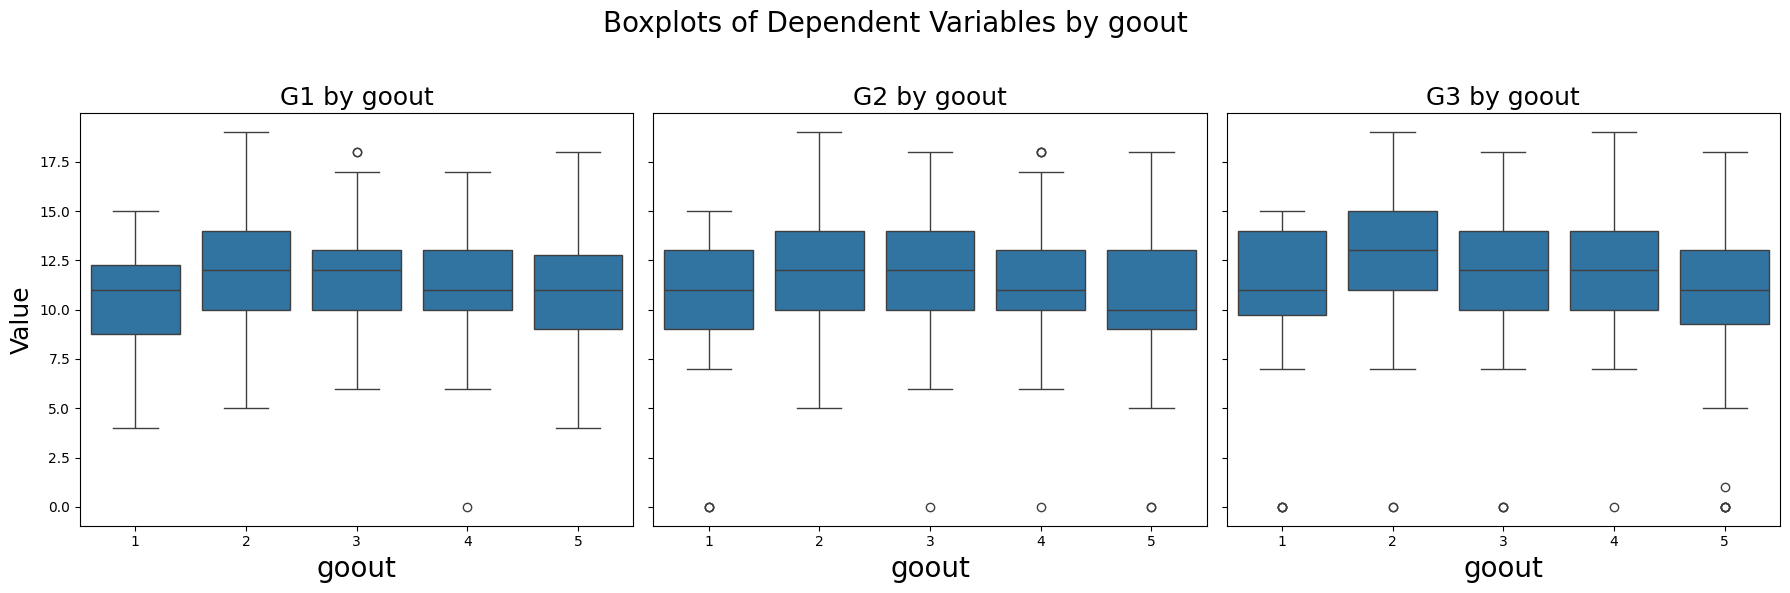

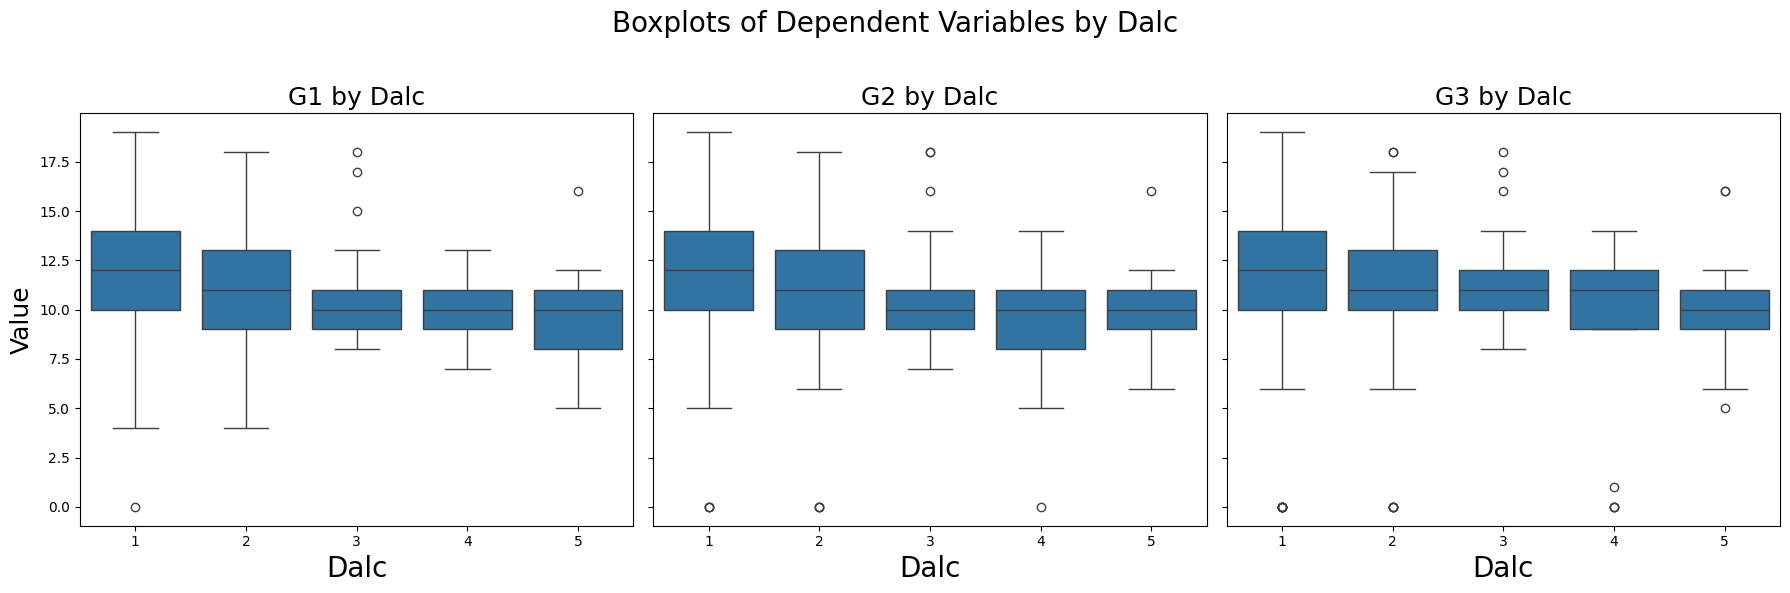

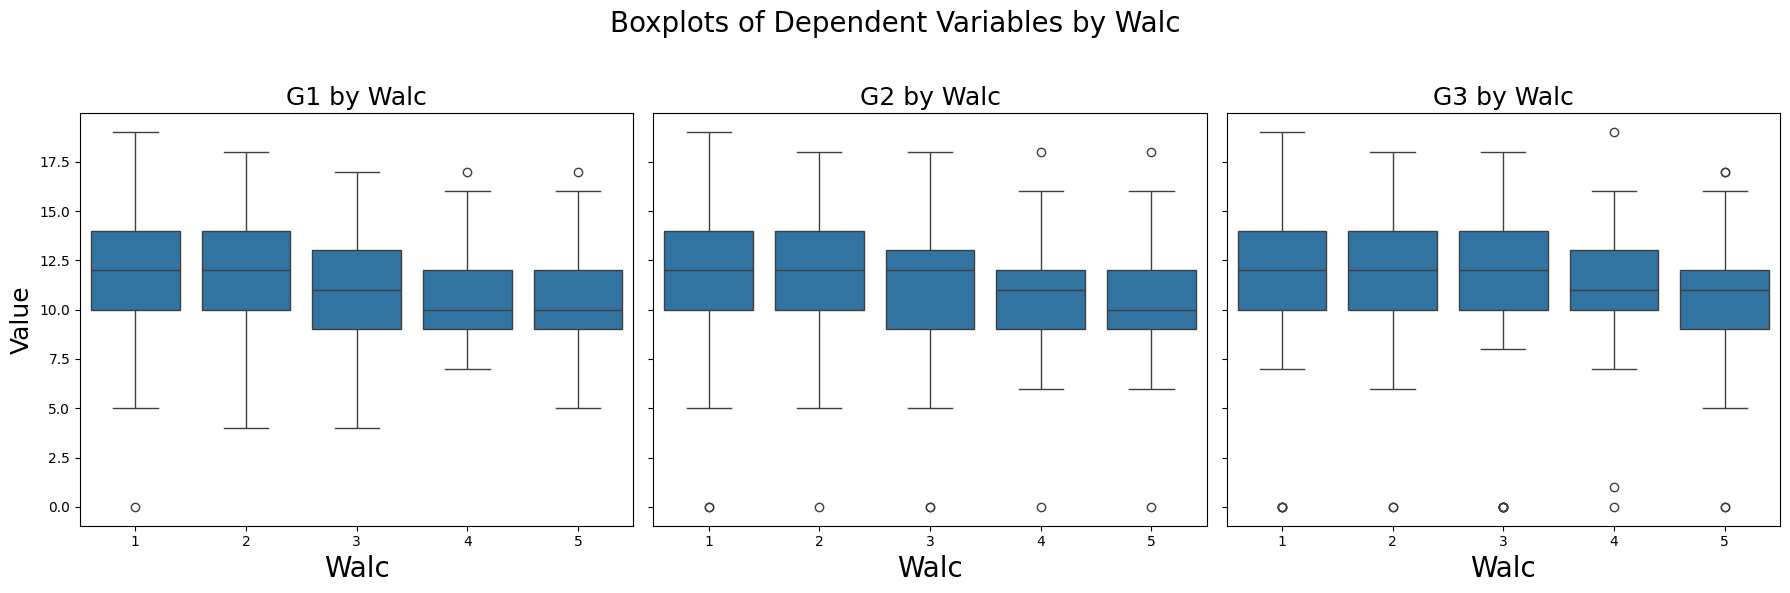

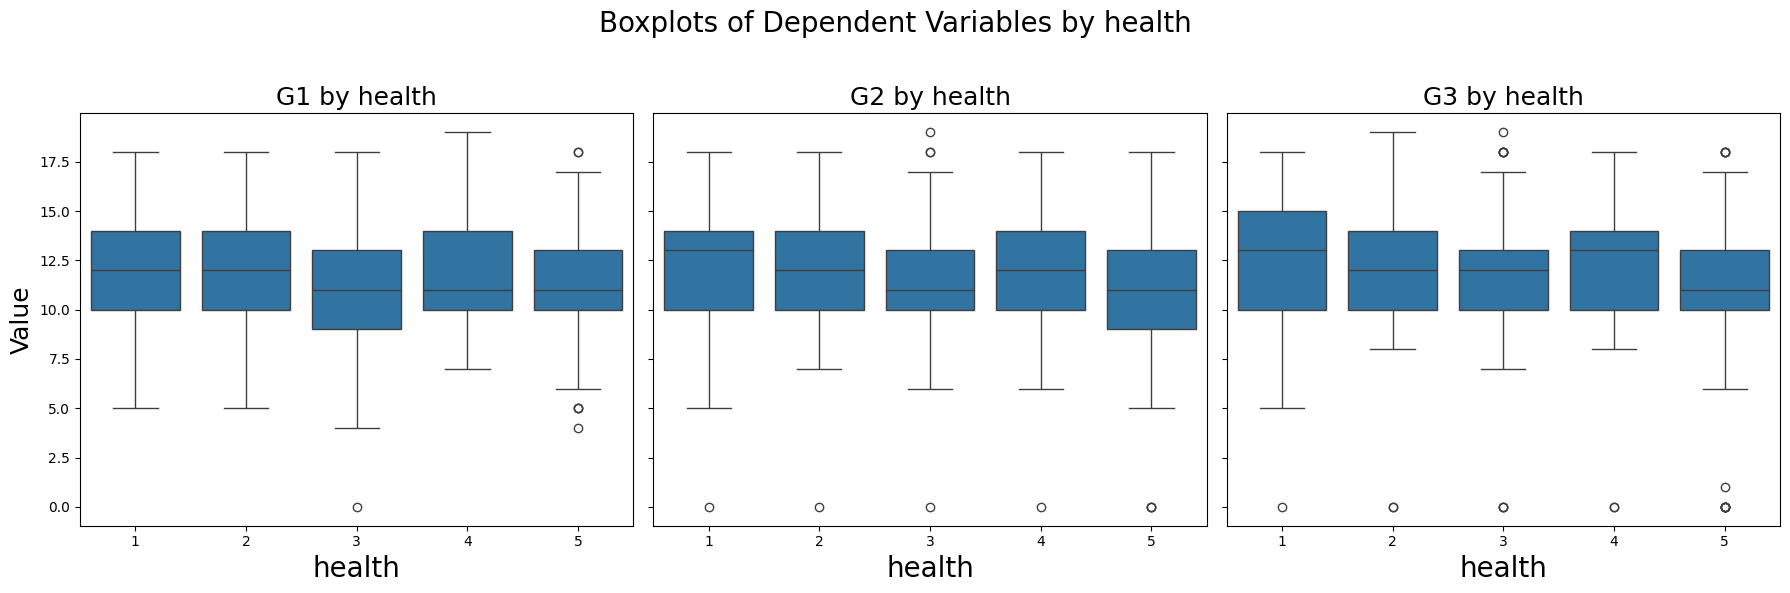

In [13]:
dependent_features = ['G1', 'G2', 'G3']
independent_features = ['school', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

for independent in independent_features:
    fig, axes = plt.subplots(1, len(dependent_features), figsize=(18, 6), sharey=True)
    fig.suptitle(f'Boxplots of Dependent Variables by {independent}', fontsize=20)

    for i, dependent in enumerate(dependent_features):
        sns.boxplot(x=data_filt_abs[independent], y=data_filt_abs[dependent], ax=axes[i])
        axes[i].set_title(f'{dependent} by {independent}', fontsize=18)
        axes[i].set_xlabel(independent, fontsize=20)
        if i == 0:  # Label the y-axis only on the first subplot for clarity
            axes[i].set_ylabel('Value', fontsize=18)
        else:
            axes[i].set_ylabel('', fontsize=18)  # Clear y-axis label for subsequent plots

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit titles
    plt.show()

## Kernel density ploty

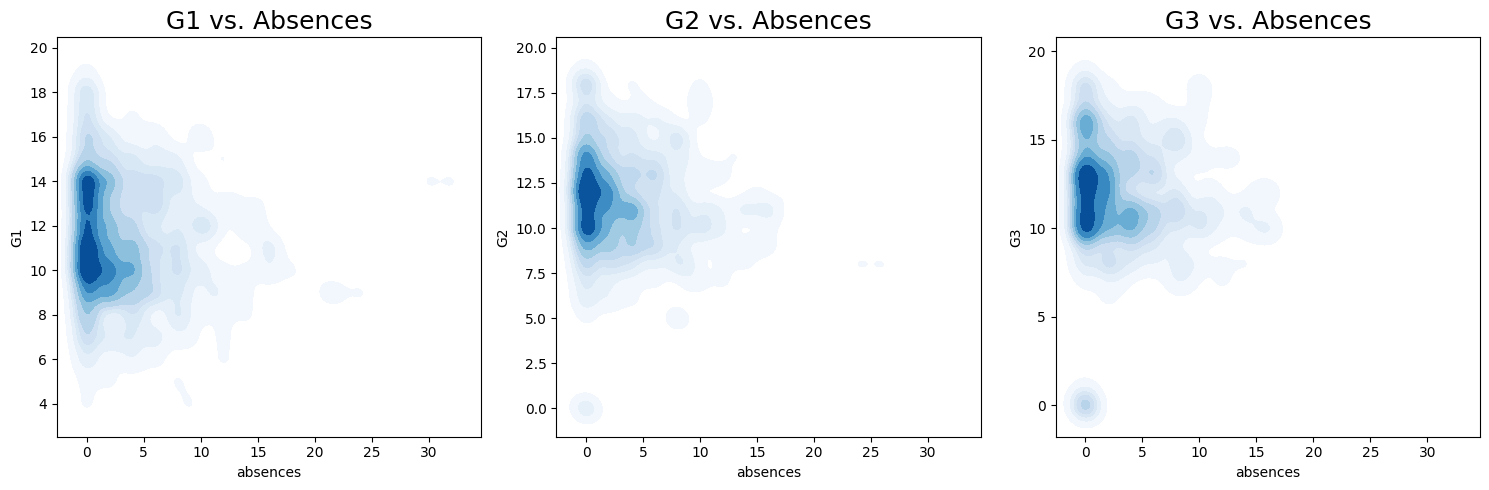

In [15]:
# Create a figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df = data_filt_nan[(data_filt_nan['absences'] != -1)]

# Plot G1 vs. absences
sns.kdeplot(x='absences', y='G1', data=df, fill=True, cmap="Blues", bw_adjust=0.5, ax=axes[0])
axes[0].set_title('G1 vs. Absences', fontsize = 18)

# Plot G2 vs. absences
sns.kdeplot(x='absences', y='G2', data=df, fill=True, cmap="Blues", bw_adjust=0.5, ax=axes[1])
axes[1].set_title('G2 vs. Absences', fontsize = 18)

# Plot G3 vs. absences
sns.kdeplot(x='absences', y='G3', data=df, fill=True, cmap="Blues", bw_adjust=0.5, ax=axes[2])
axes[2].set_title('G3 vs. Absences', fontsize = 18)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

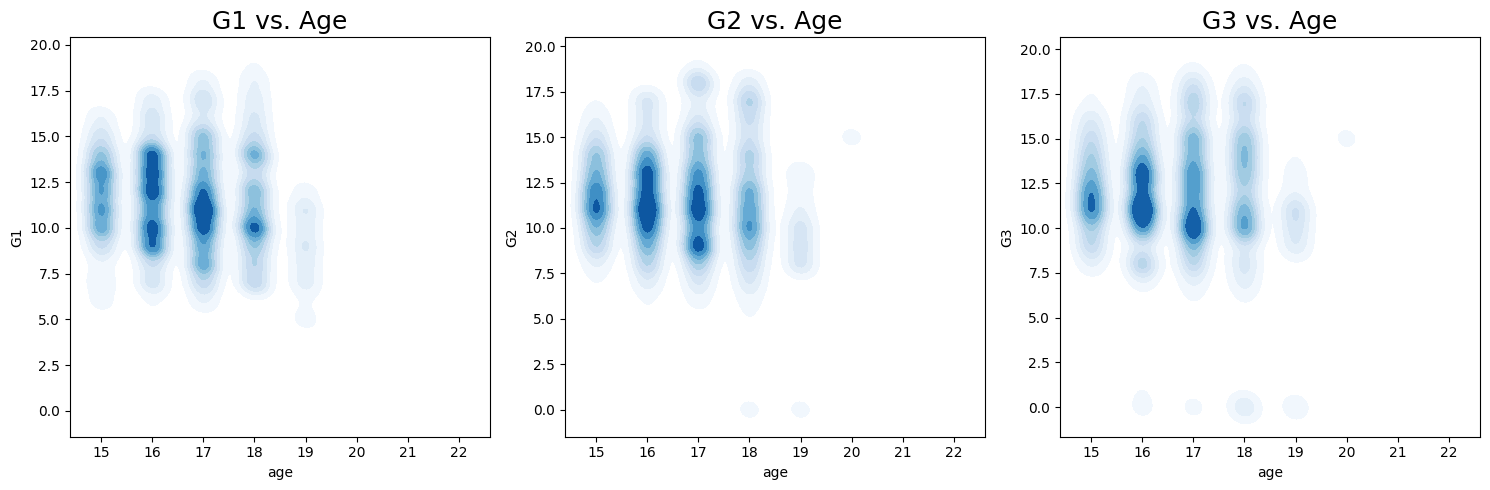

In [14]:
# Create a figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df = data_filt_nan[(data_filt_nan['age'] != 0)]

# Plot G1 vs. age
sns.kdeplot(x='age', y='G1', data=df, fill=True, cmap="Blues", bw_adjust=0.5, ax=axes[0])
axes[0].set_title('G1 vs. Age', fontsize = 18)

# Plot G2 vs. age
sns.kdeplot(x='age', y='G2', data=df, fill=True, cmap="Blues", bw_adjust=0.5, ax=axes[1])
axes[1].set_title('G2 vs. Age', fontsize = 18)

# Plot G3 vs. age
sns.kdeplot(x='age', y='G3', data=df, fill=True, cmap="Blues", bw_adjust=0.5, ax=axes[2])
axes[2].set_title('G3 vs. Age', fontsize = 18)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Binarizace "failures"

In [15]:
# Binarization of the "failures" attribute
data_code_fail = data_filt_abs
data_code_fail['failures_binary'] = data_code_fail['failures'].apply(lambda x: 1 if x > 0 else 0)
data_code_fail = data_code_fail.drop(columns=['failures'])
data_code_fail['failures_binary'].unique()
data_code_fail

,school,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,schoolsup,famsup,...,famrel,freetime,goout,Dalc,Walc,health,G1,G2,G3,failures_binary
0,GP,U,GT3,A,4,4,2,2,yes,no,...,4,3,4,1,1,3,0,11,11,0
1,GP,U,GT3,T,1,1,1,2,no,yes,...,5,3,3,1,1,3,9,11,11,0
2,GP,U,LE3,T,1,1,1,2,yes,no,...,4,3,2,2,3,3,12,13,12,0
3,GP,U,GT3,T,4,2,1,3,no,yes,...,3,2,2,1,1,5,14,14,14,0
4,GP,U,GT3,T,3,3,1,2,no,yes,...,4,3,2,1,2,5,11,13,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,R,GT3,T,2,3,1,3,no,no,...,5,4,2,1,2,5,10,11,10,1
645,MS,U,LE3,T,3,1,1,2,no,yes,...,4,3,4,1,1,1,15,15,16,0
646,MS,U,GT3,T,1,1,2,2,no,no,...,1,1,1,1,1,5,11,12,9,0
647,MS,U,LE3,T,3,1,2,1,no,no,...,2,4,5,3,4,2,10,10,10,0


# Sledování závislosti skóre na příznacích

## Ověření normality studijních skóre
Použit Shapirův-Wilkův test.

In [13]:
# List of columns to test
columns_to_test = ['G1', 'G2', 'G3']

# Loop through each column and perform the test
for column in columns_to_test:
    shapiro_test = stats.shapiro(data_filt_abs[column])

    print(f"Shapiro-Wilk Test for {column}:")
    print("Statistic:", shapiro_test.statistic)
    print("p-value:", shapiro_test.pvalue)

    alpha = 0.05  # Set your significance level

    if shapiro_test.pvalue > alpha:
        print("Normally distributed.")
    else:
        print("Not normally distributed.")
    print("-" * 20)  # Separator for better readability

Shapiro-Wilk Test for G1:
Statistic: 0.9855387350151678
p-value: 4.933520919562371e-06
Not normally distributed.
--------------------
Shapiro-Wilk Test for G2:
Statistic: 0.9616670798624192
p-value: 5.58329165502469e-12
Not normally distributed.
--------------------
Shapiro-Wilk Test for G3:
Statistic: 0.9259809367060796
p-value: 2.4159862607742257e-17
Not normally distributed.
--------------------


## Testové ověření závislosti

1. Pro ověření normality použit Lillieforsův test normality.
2. Pro testování homoskedasticity použit Leveneův test.
3. Na základě výsledků použit t-test, ANOVA, Mann-Whitney U nebo Kruskal-Wallis.

In [20]:
# Function to perform statistical tests and create visualizations
def test_dependence(dependent_variable, independent_variable):
    """
    Tests the dependence of a dependent variable on an independent variable
    using statistical tests and creates visualizations. Checks for parametric
    test assumptions before applying the test.

    Args:
        dependent_variable (str): Name of the dependent variable (G1, G2, or G3).
        independent_variable (str): Name of the independent variable (higher or failures_binary).
    """

    # Get data for groups
    groups = data_filt_abs[independent_variable].unique()
    groups_data = [data_filt_abs[data_filt_abs[independent_variable] == group][dependent_variable] for group in groups]

    # Check for normality using Lilliefors test
    normality_results = [lilliefors(group_data)[1] for group_data in groups_data]
    is_normal = all(p > 0.05 for p in normality_results)  # Assuming alpha = 0.05

    # Check for equal variances using Levene's test
    if len(groups) > 2:
        levene_statistic, levene_p_value = stats.levene(*groups_data)
        equal_variances = levene_p_value > 0.05  # Assuming alpha = 0.05
    else:
        equal_variances = True  # For two groups, t-test handles unequal variances

    # Choose appropriate test based on assumptions
    if is_normal and equal_variances:
        if len(groups) == 2:
            t_statistic, p_value = stats.ttest_ind(*groups_data)
            test_name = "t-test"
        else:
            f_statistic, p_value = stats.f_oneway(*groups_data)
            test_name = "ANOVA"
    else:
        if len(groups) == 2:
            u_statistic, p_value = stats.mannwhitneyu(*groups_data)
            test_name = "Mann-Whitney U"
        else:
            h_statistic, p_value = stats.kruskal(*groups_data)
            test_name = "Kruskal-Wallis"

    print(f"Dependence of {dependent_variable} on {independent_variable}:")
    print(f"{test_name}: statistic = {t_statistic if test_name == 't-test' else f_statistic if test_name == 'ANOVA' else u_statistic if test_name == 'Mann-Whitney U' else h_statistic:.2f}, p-value = {p_value:.4f}")
    return p_value

Ověření závislosti pozorované v boxplotech, tedy u příznaků "higher" a "failures" (binarizovaný).

In [21]:
# Test dependence for G1, G2, and G3 scores on 'higher' and 'failures_binary'
for dependent_var in ['G1', 'G2', 'G3']:
  for independent_var in ['higher', 'failures_binary']:
    test_dependence(dependent_var, independent_var)

Dependence of G1 on higher:
Mann-Whitney U: statistic = 33369.50, p-value = 0.0000
Dependence of G1 on failures_binary:
Mann-Whitney U: statistic = 46256.50, p-value = 0.0000
Dependence of G2 on higher:
Mann-Whitney U: statistic = 32907.00, p-value = 0.0000
Dependence of G2 on failures_binary:
Mann-Whitney U: statistic = 46415.50, p-value = 0.0000
Dependence of G3 on higher:
Mann-Whitney U: statistic = 33163.50, p-value = 0.0000
Dependence of G3 on failures_binary:
Mann-Whitney U: statistic = 46978.50, p-value = 0.0000


Sledování závislosti příznaku "failures" jako spojité veličiny na studijním skóre.

In [39]:
results = []

for col in ['G1', 'G2', 'G3']:
    spearman_corr, spearman_p = spearmanr(data_filt_abs['failures'], data_filt_abs[col])
    results.append({
        'Variable': col,
        'Spearman Correlation': round(spearman_corr, 3),
        'Spearman p-value': spearman_p if spearman_p >= 0.001 else 0.001
    })


results_df = pd.DataFrame(results)
print("Correlation between G scores and failures:")
print(results_df)

Correlation between G scores and failures:
  Variable  Spearman Correlation  Spearman p-value
0       G1                -0.432             0.001
1       G2                -0.436             0.001
2       G3                -0.448             0.001


## Sledování závislosti skóre na vybraných příznacích a kombinacích příznaků

**JEDNOTLIVÉ PŘÍZNAKY**
- typ školy (school)
- vzdělání rodičů (Fedu, Medu)
- pohlaví (sex)
- čas věnovaný studiu (studytime)
- podpora od rodiny (famsup)
- počet dřívějších studijních neúspěchů (failures)
- výukové aktivity mimo rozvrh (activities)

Dependence of G1 on school:
Mann-Whitney U: statistic = 65201.00, p-value = 0.0000
Dependence of G2 on school:
Mann-Whitney U: statistic = 63263.00, p-value = 0.0000
Dependence of G3 on school:
Mann-Whitney U: statistic = 64220.50, p-value = 0.0000
Dependence of G1 on Medu:
Kruskal-Wallis: statistic = 53.71, p-value = 0.0000
Dependence of G2 on Medu:
Kruskal-Wallis: statistic = 57.57, p-value = 0.0000
Dependence of G3 on Medu:
Kruskal-Wallis: statistic = 57.22, p-value = 0.0000
Dependence of G1 on Fedu:
Kruskal-Wallis: statistic = 37.59, p-value = 0.0000
Dependence of G2 on Fedu:
Kruskal-Wallis: statistic = 40.22, p-value = 0.0000
Dependence of G3 on Fedu:
Kruskal-Wallis: statistic = 36.79, p-value = 0.0000
Dependence of G1 on studytime:
Kruskal-Wallis: statistic = 47.76, p-value = 0.0000
Dependence of G2 on studytime:
Kruskal-Wallis: statistic = 45.31, p-value = 0.0000
Dependence of G3 on studytime:
Kruskal-Wallis: statistic = 50.32, p-value = 0.0000
Dependence of G1 on famsup:
Mann-W

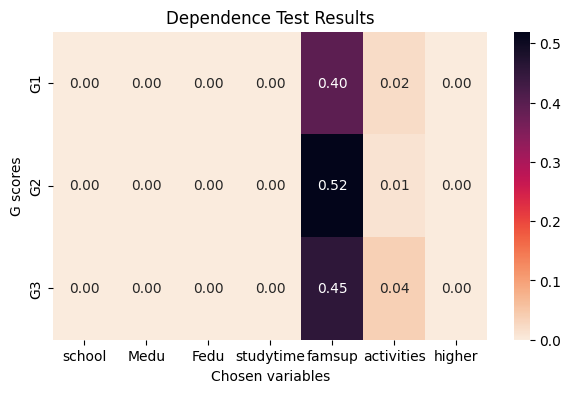

In [40]:
# Get dependence of G1, G2, G3 score on chosen variables

independent_vars = ['school', 'Medu', 'Fedu', 'studytime', 'famsup', 'activities', 'higher']
dependent_vars = ['G1', 'G2', 'G3']
results = {}

for independent_var in independent_vars:
  for dependent_var in dependent_vars:
    if independent_var not in results:
        results[independent_var] = {}
    results[independent_var][dependent_var] = test_dependence(dependent_var, independent_var)

results_df = pd.DataFrame(results)
plt.figure(figsize=(7, 4))
sns.heatmap(results_df, annot=True, cmap="rocket_r", fmt=".2f")
plt.title("Dependence Test Results")
plt.xlabel("Chosen variables")
plt.ylabel("G scores")
plt.show()

**KOMBINACE PŘÍZNAKŮ**
- mimoškolní aktivity (activities, goout, freetime) a míra času věnovanému studia (studytime)
- demografické faktory: místo bydliště (address), velikost rodiny (famsize), trvání cesty do školy (traveltime)

In [18]:
!pip install scikit-posthocs==0.6.7

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-posthocs: filename=scikit_posthocs-0.6.7-py3-none-any.whl size=37887 sha256=2fc44d0e1261690a384e2ce9682a6b7e764eca7820e7de10b9605663c219f26f
  Stored in directory: /root/.cache/pip/wheels/40/eb/7b/6546919b28fc4b40fb4de37f9801977537a64fcc0a2950b6c6
Successfully built scikit-posthocs


1. **Shapiro-Wilk test** normality (Pokud všechny p-hodnoty z testu > 0.05, je považováno, že data jsou normální.)
2.  **Leveneův test** homogenity rozptylů (Pokud p-hodnota > 0.05, předpokládáme stejný rozptyl (homogenitu).)
3. Na základě výsledků testů normality a homogenity rozptylů se vybírá: **ANOVA** (data normální, shodný rozptyl), **Kruskal-Wallisův test** (nenormální data nebo rozdílné rozptyly)
4. Post-hoc analýza (Pokud byl hlavní test statisticky významný p < 0.05), provádí se: **Dunnův post-hoc test** (po Kruskal-Wallisovi)= Porovnává dvojice skupin a identifikuje, které se statisticky významně liší. **Tukey HSD test** (po ANOVA)


Analysis for G1 variable

Combination: activities_goout_freetime
Statistic: 64.2844007281378
p-value: 0.047594655528515814
Test Used: Kruskal-Wallis
Normal: False
Equal Variances: True


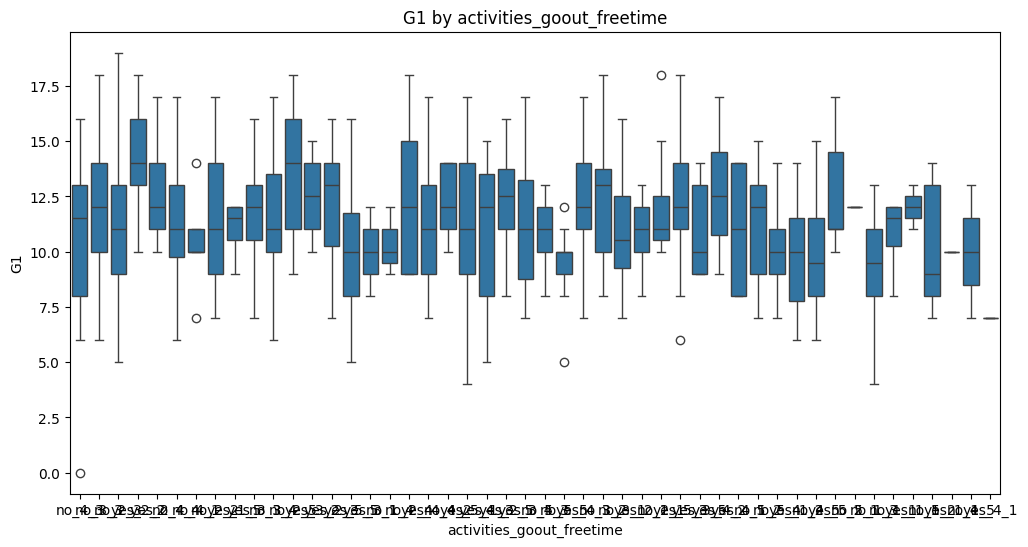

Combination: address_famsize_traveltime
Statistic: 36.700148942240595
p-value: 0.0013995318833744557
Test Used: Kruskal-Wallis
Normal: False
Equal Variances: True
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - R_GT3_2 vs U_LE3_1: p = 0.040
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - U_LE3_1 vs R_GT3_2: p = 0.040


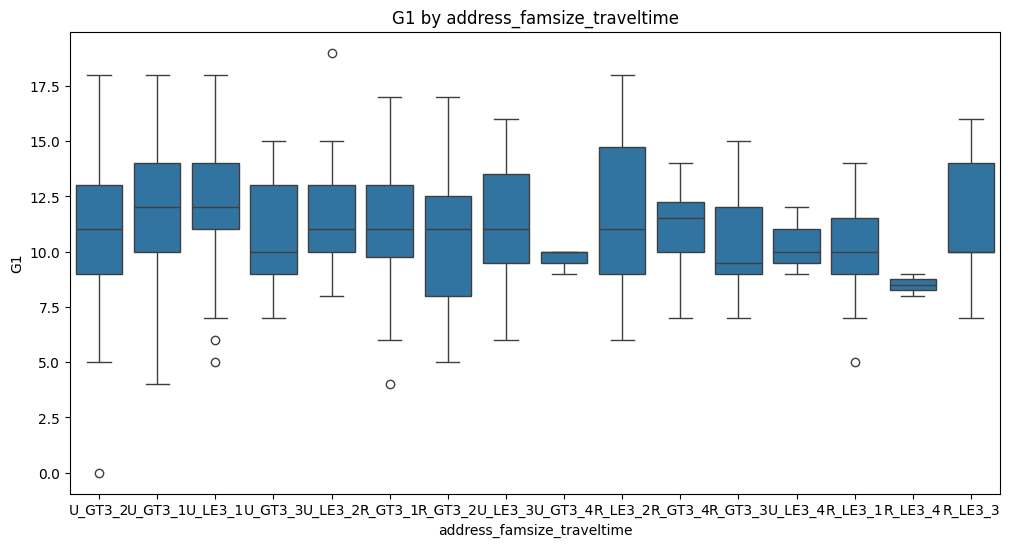


Analysis for G2 variable

Combination: activities_goout_freetime
Statistic: 75.89298336615302
p-value: 0.004797823582933862
Test Used: Kruskal-Wallis
Normal: False
Equal Variances: True
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - no_5_5 vs yes_2_2: p = 0.020
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - yes_2_2 vs no_5_5: p = 0.020


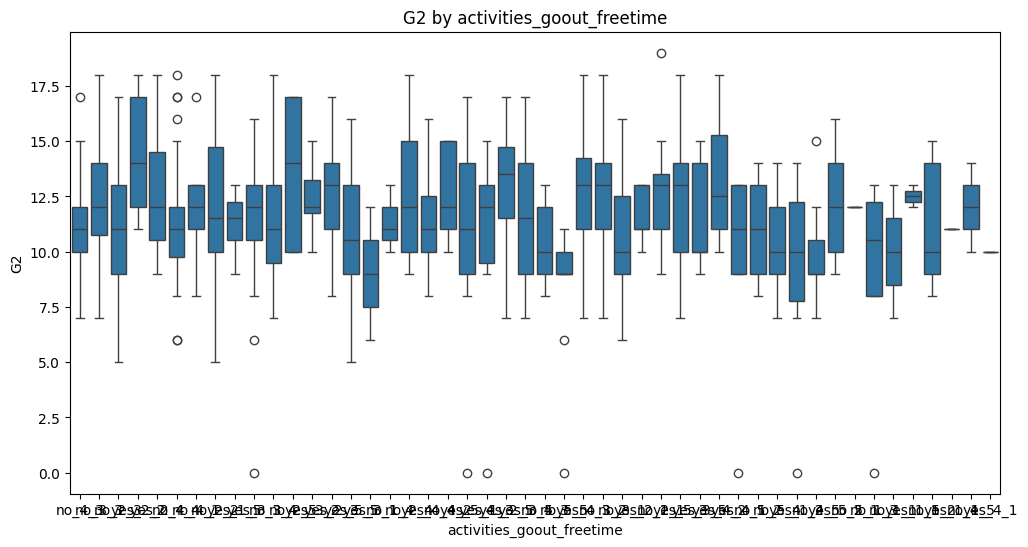

Combination: address_famsize_traveltime
Statistic: 38.09254755678727
p-value: 0.000874308976332044
Test Used: Kruskal-Wallis
Normal: False
Equal Variances: True
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - R_GT3_3 vs U_LE3_1: p = 0.048
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - U_LE3_1 vs R_GT3_3: p = 0.048


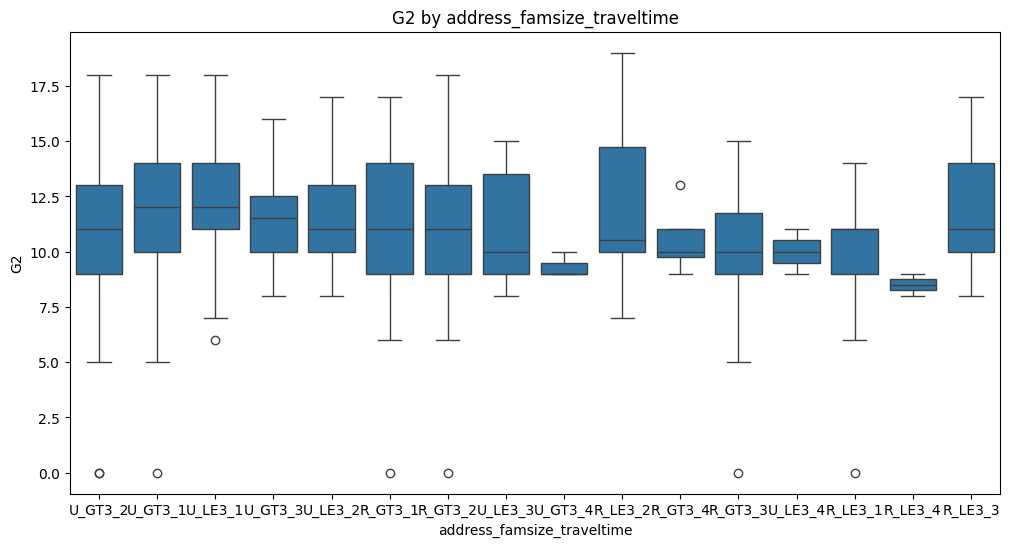


Analysis for G3 variable

Combination: activities_goout_freetime
Statistic: 76.959786728515
p-value: 0.0037918286587833167
Test Used: Kruskal-Wallis
Normal: False
Equal Variances: True
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - no_5_5 vs yes_2_2: p = 0.005
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - yes_2_2 vs no_5_5: p = 0.005


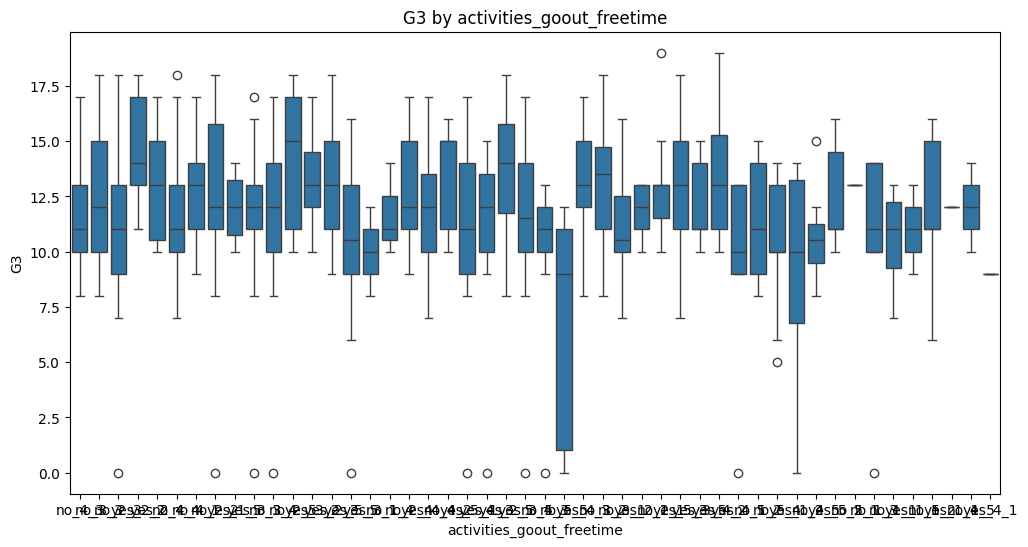

Combination: address_famsize_traveltime
Statistic: 34.48120858523246
p-value: 0.0029131858293992064
Test Used: Kruskal-Wallis
Normal: False
Equal Variances: True


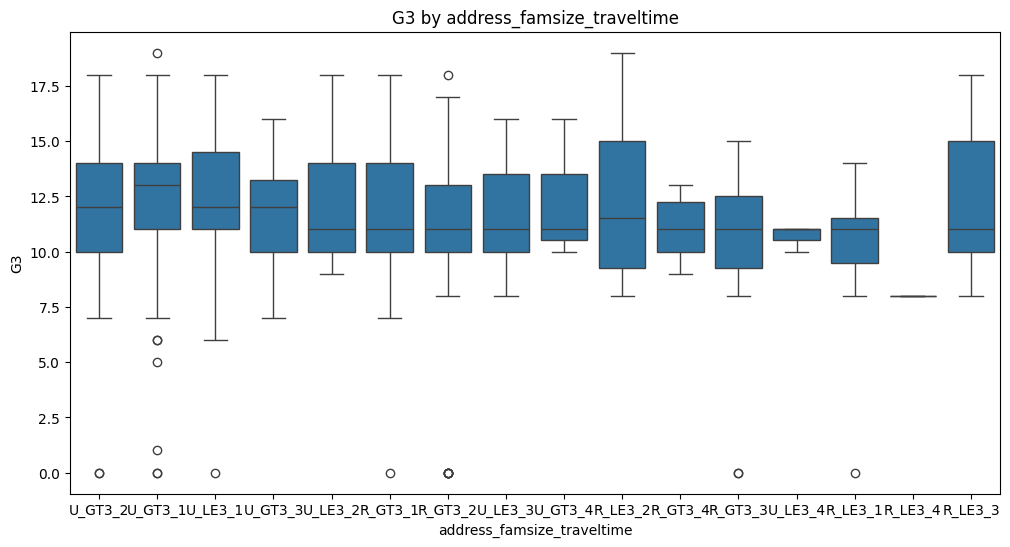

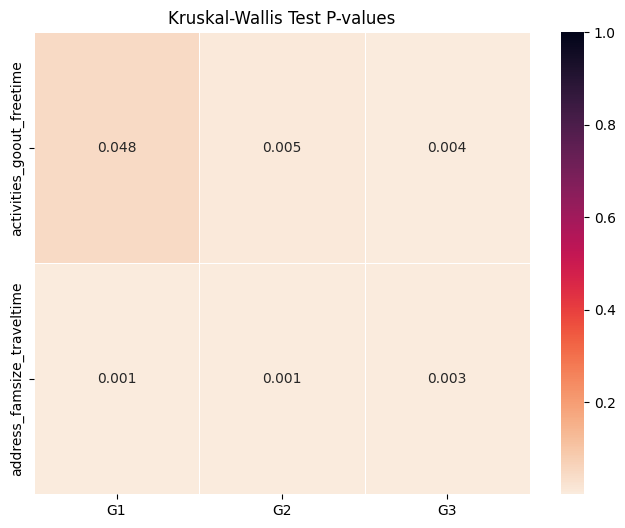

In [37]:
import scikit_posthocs as sp

# Specify the combination of 3 variables
combos = [('activities', 'goout', 'freetime'), ('address', 'famsize', 'traveltime')]
dependent = ['G1', 'G2', 'G3']
all_p_values = {}

for dep_var in dependent:
  print(f'\nAnalysis for {dep_var} variable\n')
  p_values = {}
  for combo in combos:
    # Combine variables into a single category
    combined_name = '_'.join(combo)
    data_filt_abs[combined_name] = data_filt_abs[list(combo)].astype(str).agg('_'.join, axis=1)

    # Group scores by combined category
    groups = [data_filt_abs[data_filt_abs[combined_name] == cat][dep_var] for cat in data_filt_abs[combined_name].unique()]

    # 1. Check normality using Shapiro-Wilk test
    normality_p_values = [shapiro(group)[1] for group in groups if len(group) > 2]
    is_normal = all(p > 0.05 for p in normality_p_values)

    # 2. Check homogeneity of variances using Levene's test
    if len(groups) > 2:
        equal_variances = levene(*[group for group in groups if len(group) > 1])[1] > 0.05
    else:
        equal_variances = np.nan

    # 3. Choose appropriate test based on normality and variance equality
    if is_normal and equal_variances:
        # Perform one-way ANOVA
        from scipy.stats import f_oneway
        stat, p = f_oneway(*groups)
        test_used = 'ANOVA'
    else:
        # Perform Kruskal-Wallis test
        stat, p = kruskal(*groups)
        test_used = 'Kruskal-Wallis'
    p_values[combined_name] = p

    # Print results
    print(f"Combination: {combined_name}")
    print(f"Statistic: {stat}")
    print(f"p-value: {p}")
    print(f"Test Used: {test_used}")
    print(f"Normal: {is_normal}")
    print(f"Equal Variances: {equal_variances}")

    # 4. Post-hoc test (if Kruskal-Wallis and significant)
    if test_used == 'Kruskal-Wallis' and p < 0.05:
        post_hoc_result = sp.posthoc_dunn(data_filt_abs, val_col=dep_var, group_col=combined_name, p_adjust='bonferroni')
        significant_results = post_hoc_result[post_hoc_result < 0.05]

        if significant_results.empty:
            print(f"No significant differences found for {combined_name}.")
        else:
            for index, row in significant_results.iterrows():
                for column in significant_results.columns:
                    p_value = row[column]
                    if not pd.isnull(p_value):
                        print("Significant Differences (Dunn's Post Hoc Test, p < 0.05):")
                        print(f" - {index} vs {column}: p = {p_value:.3f}")


    # Alternatively, perform pairwise Tukey HSD test after ANOVA (if ANOVA and significant)
    if test_used == 'ANOVA' and p < 0.05:
        data = data_filt_abs[[dep_var, combined_name]].copy()
        data[combined_name] = data[combined_name].astype('category')
        posthoc = pairwise_tukeyhsd(data[dep_var], data[combined_name], alpha=0.05)
        print(f"Post-hoc test for {combined_name}:\n{posthoc}\n")

    plt.figure(figsize=(12, 6))
    sns.boxplot(x=combined_name, y=dep_var, data=data_filt_abs)
    plt.title(f'{dep_var} by {combined_name}')
    plt.show()

    all_p_values[dep_var] = p_values

p_values_df = pd.DataFrame(all_p_values) # Convert to DataFrame for heatmap
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(p_values_df, annot=True, cmap="rocket_r", fmt=".3f", linewidths=0.5, vmax=1)
heatmap.set_title("Kruskal-Wallis Test P-values")
plt.show()

Pro G1 address_famsize_traveltime:
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - R_GT3_2 vs U_LE3_1: p = 0.040

*Statisticky významný rozdíl mezi skupinou studentů, kteří žijí na vesnici, mají více než 3 členy rodiny a cesta do školy jim trvá 15 až 30 minut a skupinou studentů, kteří žijí ve městě, mají 3 a méně členů rodiny a cesta do školy jim trvá méně než 15 minut.*

Pro G2 activities_goout_freetime:
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - no_5_5 vs yes_2_2: p = 0.020

*Skupina studentů, kteří nemají výukové mimoškolní aktivity, velmi hodně chodí ven a mají až příliš volného času, se významně liší od skupiny studentů, kteří mají výukové mimoškolní aktivity, mají málo volného času a málo chodí ven.*

Pro G2 address_famsize_traveltime
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
- R_GT3_3 vs U_LE3_1: p = 0.048

*Statisticky významný rozdíl mezi skupinou studentů, kteří žijí na vesnici, mají více než 3 členy rodiny a cesta do školy jim trvá 30 min až 1 hodinu a skupinou studentů, kteří žijí ve městě, mají 3 a méně členů rodiny a cesta do školy jim trvá méně než 15 minut.*

Pro G3 activities_goout_freetime
Significant Differences (Dunn's Post Hoc Test, p < 0.05):
 - no_5_5 vs yes_2_2: p = 0.005

*Skupina studentů, kteří nemají výukové mimoškolní aktivity, velmi hodně chodí ven a mají až příliš volného času, se významně liší od skupiny studentů, kteří mají výukové mimoškolní aktivity, mají málo volného času a málo chodí ven.*

# Sledování závislosti studijních skóre v ročnících

## Scatterploty

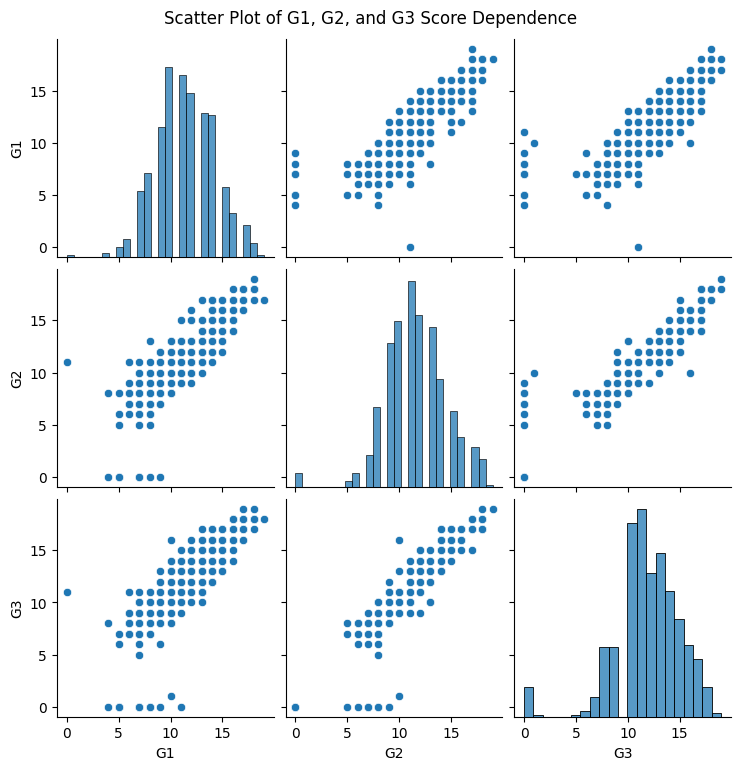

In [41]:
# Plot the scatter plot of G1, G2, G3 score dependence on each other
sns.pairplot(data_filt_abs[['G1', 'G2', 'G3']])
plt.suptitle('Scatter Plot of G1, G2, and G3 Score Dependence', y=1.02)
plt.show()

## Korelační matice
Použit Spearmanův korelační koeficient.

          G1        G2        G3
G1  1.000000  0.864982  0.826387
G2  0.864982  1.000000  0.918548
G3  0.826387  0.918548  1.000000


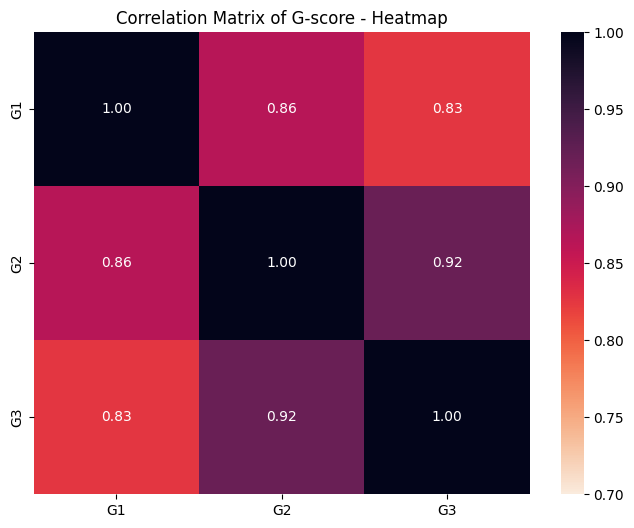


P-values Table:
     G1   G2   G3
G1  0.0  0.0  0.0
G2  0.0  0.0  0.0
G3  0.0  0.0  0.0


<ipython-input-43-43cdd0bf1adb>:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues[r][c] = spearmanr(df[r], df[c])[1]


In [43]:
# Get correlation of G1, G2, G3 score between each other
correlation_matrix = data_filt_abs[['G1', 'G2', 'G3']].corr()
print(correlation_matrix)

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket_r', fmt=".2f", vmin=0.7, vmax=1)
plt.title('Correlation Matrix of G-score - Heatmap')
plt.show()

def calculate_pvalues(df):
     dfcols = pd.DataFrame(columns=df.columns)
     pvalues = dfcols.transpose().join(dfcols, how='outer')
     for r in df.columns:
         for c in df.columns:
             pvalues[r][c] = spearmanr(df[r], df[c])[1]
     return pvalues


# H0: there is no correlation between variables
p_values = calculate_pvalues(data_filt_abs[['G1', 'G2', 'G3']])
print("\nP-values Table:")
print(p_values)

## Lineární regrese

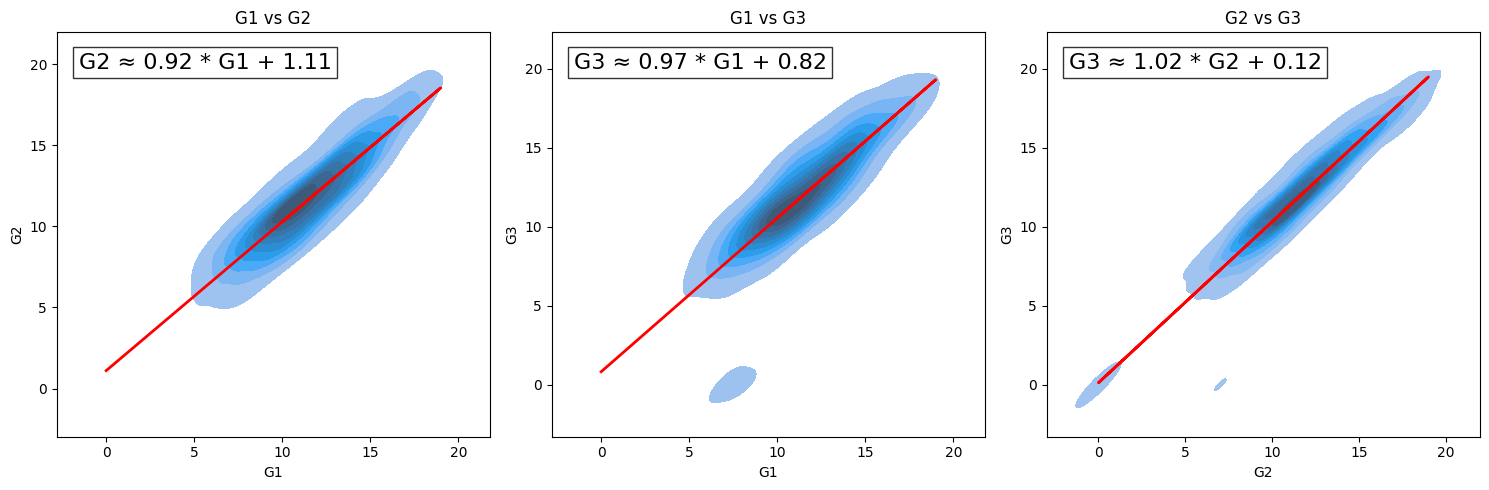

In [44]:
# Get all combinations of scores
score_combinations = list(combinations(['G1', 'G2', 'G3'], 2))

# Create subplots for each combination
fig, axes = plt.subplots(1, len(score_combinations), figsize=(15, 5))

for i, (score1, score2) in enumerate(score_combinations):
    x = data_filt_abs[score1].values.reshape(-1, 1)
    y = data_filt_abs[score2].values

    # Create and fit the model
    model = LinearRegression()
    model.fit(x, y)

    # Get coefficients
    slope = model.coef_[0]
    intercept = model.intercept_

    # Plot scatter plot and regression line
    # axes[i].scatter(x, y, alpha=0.7)
    sns.kdeplot(x = data_filt_abs[score1], y = data_filt_abs[score2], ax=axes[i], fill=True)
    axes[i].plot(x, model.predict(x), color='red', linewidth=2)
    axes[i].set_xlabel(score1)
    axes[i].set_ylabel(score2)
    axes[i].set_title(f'{score1} vs {score2}')

    # Add equation to the plot
    equation = f'{score2} ≈ {slope:.2f} * {score1} + {intercept:.2f}'
    axes[i].text(0.05, 0.95, equation, transform=axes[i].transAxes, fontsize=16,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Predicted G3 ≈ 0.15 · G1 + 0.90 · G2 + -0.17


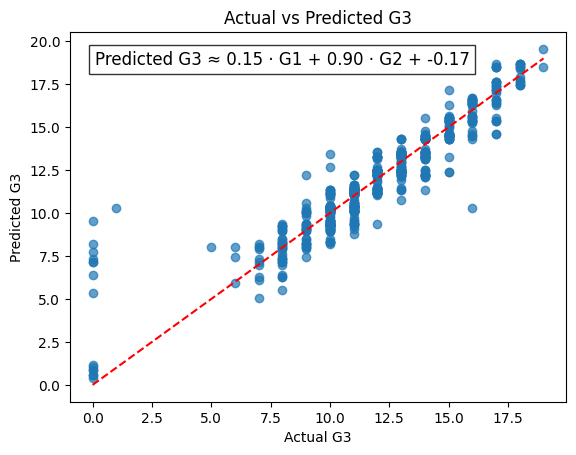

R-squared: 0.85


In [ ]:
# Prepare the data
X = data_filt_abs[['G1', 'G2']]  # Independent variables (G1 and G2)
y = data_filt_abs['G3']  # Dependent variable (G3)

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Get coefficients
coefficients = model.coef_
intercept = model.intercept_
equation = f'Predicted G3 ≈ {coefficients[0]:.2f} · G1 + {coefficients[1]:.2f} · G2 + {intercept:.2f}'

# Print the equation
print(equation)

# Predict G3 values using the model
predicted_G3 = model.predict(X)

# Plot the predicted vs actual values
plt.scatter(y, predicted_G3, alpha=0.7)
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')  # Add a diagonal line for reference
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted G3')
plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
plt.show()

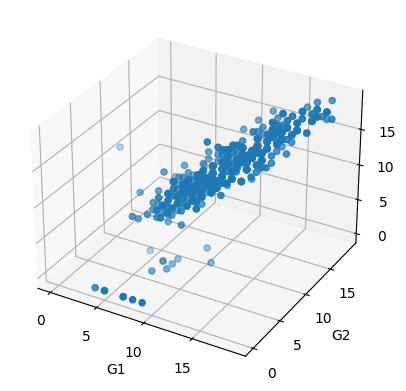

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     1799.
Date:                Mon, 09 Dec 2024   Prob (F-statistic):          9.02e-265
Time:                        11:32:29   Log-Likelihood:                -1070.7
No. Observations:                 649   AIC:                             2147.
Df Residuals:                     646   BIC:                             2161.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1713      0.215     -0.796      0.4

In [ ]:
import statsmodels.formula.api as sm
# visualization of dependence of G3 on G1 and G2
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data_filt_abs['G1'], data_filt_abs['G2'], data_filt_abs['G3'])

ax.set_xlabel('G1')
ax.set_ylabel('G2')
ax.set_zlabel('G3')

plt.show()

# linear regression
model = sm.ols(formula='G3 ~ G1 + G2', data=data_filt_abs)
results = model.fit()
print(results.summary())

#Sledování vzájemné závislosti příznaků

## Chí-kvadrát test

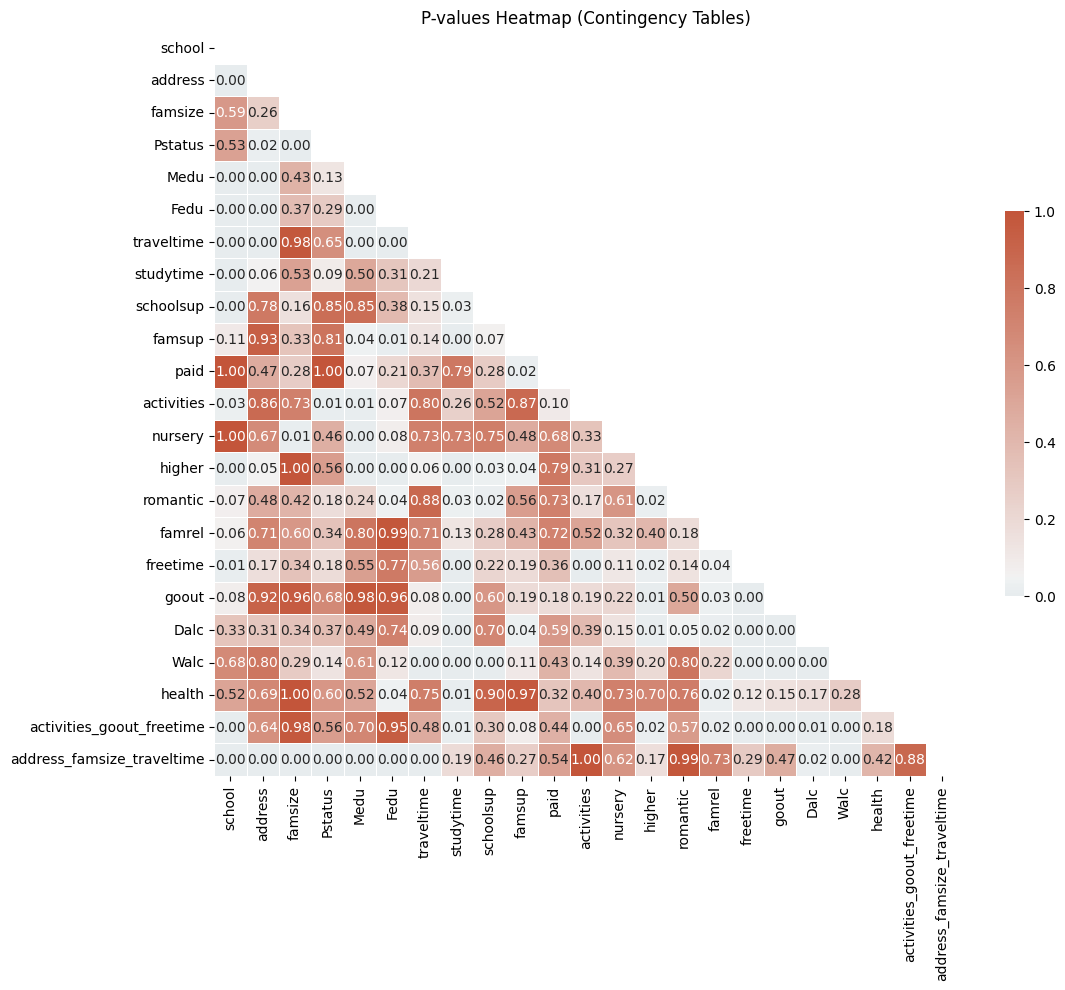

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import Table

alpha = 0.05
p_values = {}

df_chisquare = data_filt_abs.drop(columns=['G1', 'G2', 'G3', 'failures', 'failures_binary'])

for variable in df_chisquare.columns:
  p_values[variable] = {}
  for variable2 in df_chisquare.columns:
    contingency_table = pd.crosstab(data_filt_abs[variable], data_filt_abs[variable2])
    # print(contingency_table)

    if contingency_table.shape == (2, 2):
        # Fisher's Exact Test for 2x2 tables
        oddsratio, p = fisher_exact(contingency_table)
        # print(f"Fisher's Exact Test: p-value = {p:.4f}")
    else:
        # Perform Chi-Square Test with automatic handling for expected frequencies
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        if np.any(expected < 5):
            # Use G-Test if expected frequencies are too low
            g, p_g, _, _ = chi2_contingency(contingency_table, lambda_="log-likelihood")
            # print(f"G-Test: G = {g:.4f}, p-value = {p_g:.4f}")
        # else:
            # print(f"Chi-Square Test: chi2 = {chi2:.4f}, p-value = {p:.4f}")
    p_values[variable][variable2] = p

# Convert the dictionary to a DataFrame
p_values_df = pd.DataFrame(p_values)


# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(p_values_df, dtype=bool))  # Mask for upper triangle
cmap = sns.diverging_palette(220, 20, as_cmap=True)  # Diverging colormap

sns.heatmap(p_values_df, mask=mask, cmap=cmap, center=0.05, annot=True, fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('P-values Heatmap (Contingency Tables)')
plt.show()

## Grouped bar charty

address    R    U
higher           
no        28   41
yes      169  411
Fisher's Exact Test: p-value = 0.0537


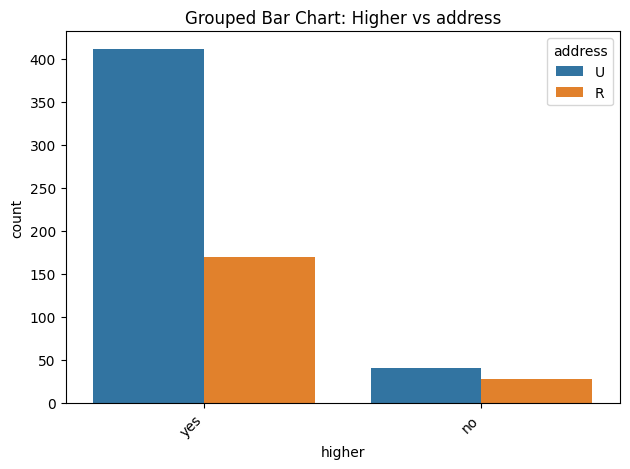

famsize  GT3  LE3
higher           
no        49   20
yes      408  172
Fisher's Exact Test: p-value = 1.0000


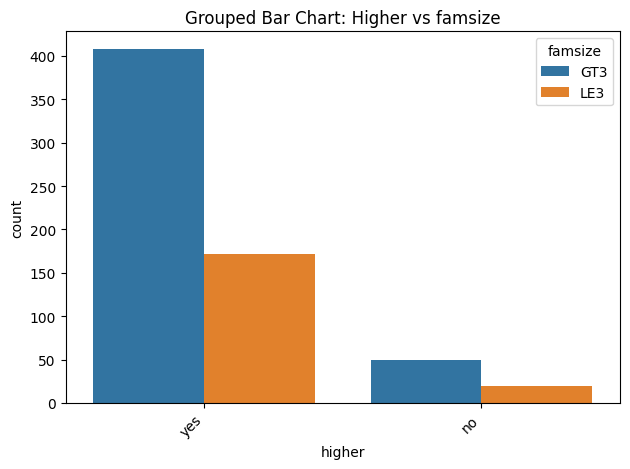

Pstatus   A    T
higher          
no       10   59
yes      70  510
Fisher's Exact Test: p-value = 0.5615


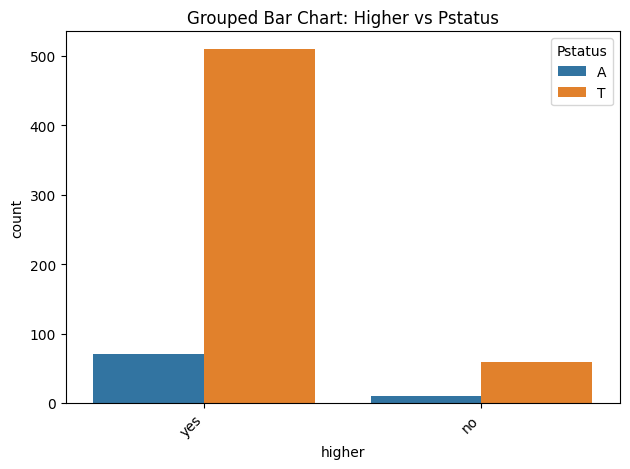

Medu    0    1    2    3    4
higher                       
no      1   27   27   12    2
yes     5  116  159  127  173
G-Test: G = 38.0431, p-value = 0.0000


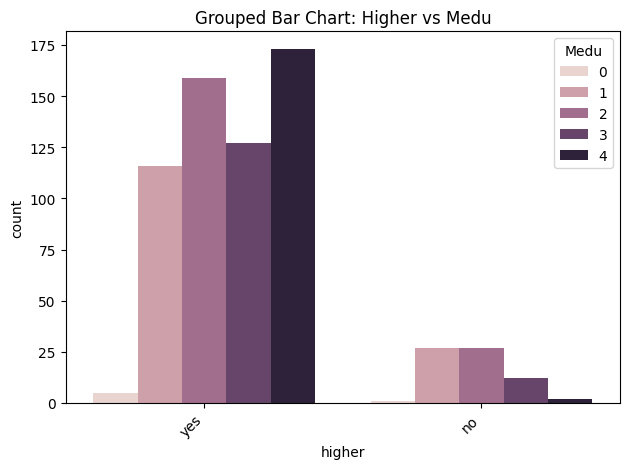

Fedu    0    1    2    3    4
higher                       
no      0   33   26    8    2
yes     7  141  183  123  126
G-Test: G = 32.8207, p-value = 0.0000


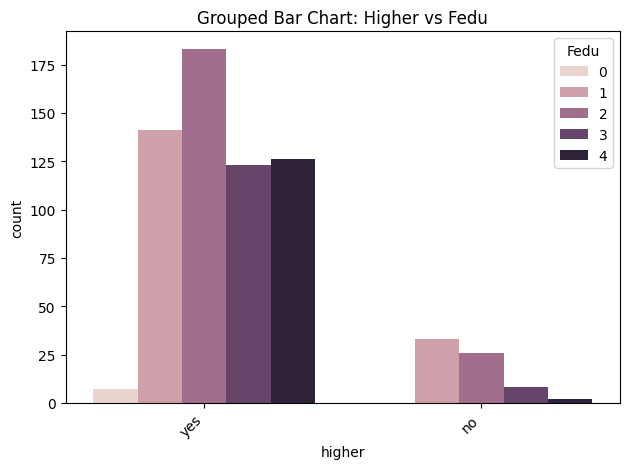

traveltime    1    2   3   4
higher                      
no           29   31   8   1
yes         337  182  46  15
G-Test: G = 7.4735, p-value = 0.0582


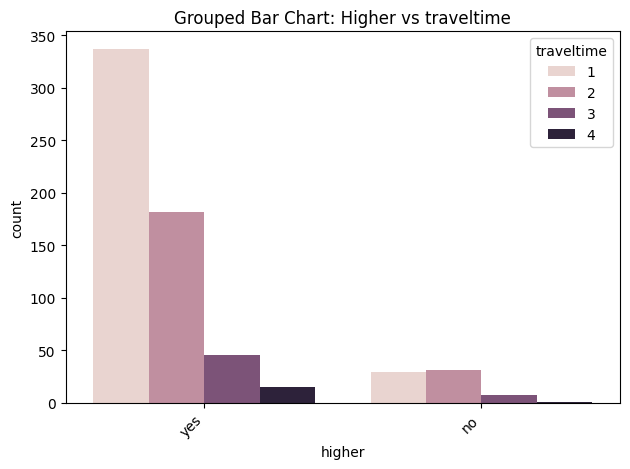

studytime    1    2   3   4
higher                     
no          44   19   4   2
yes        168  286  93  33
G-Test: G = 32.2138, p-value = 0.0000


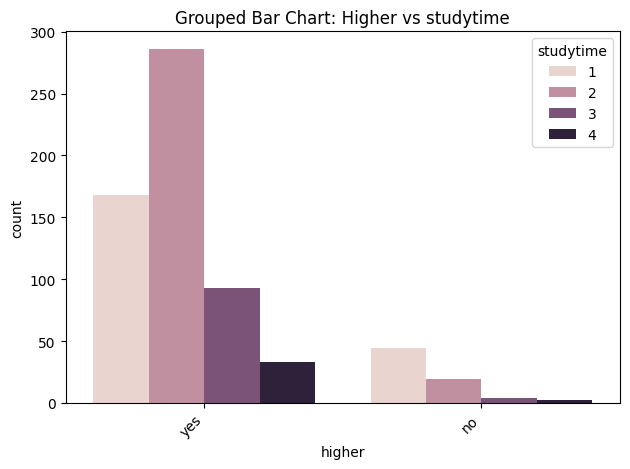

failures    0   1  2  3
higher                 
no         36  20  7  6
yes       513  50  9  8
G-Test: G = 49.1274, p-value = 0.0000


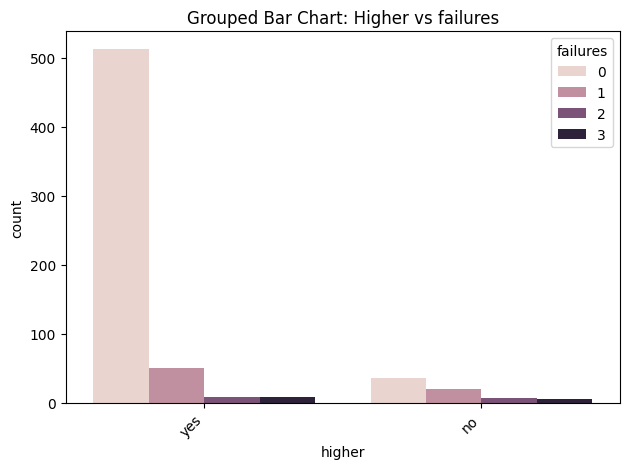

schoolsup   no  yes
higher             
no          67    2
yes        514   66
Fisher's Exact Test: p-value = 0.0347


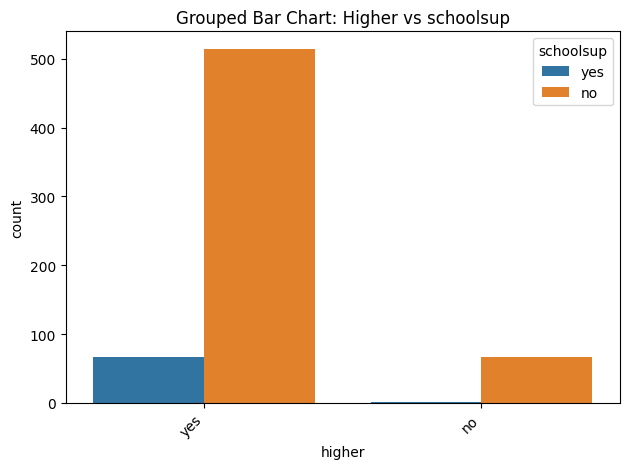

famsup   no  yes
higher          
no       35   34
yes     216  364
Fisher's Exact Test: p-value = 0.0361


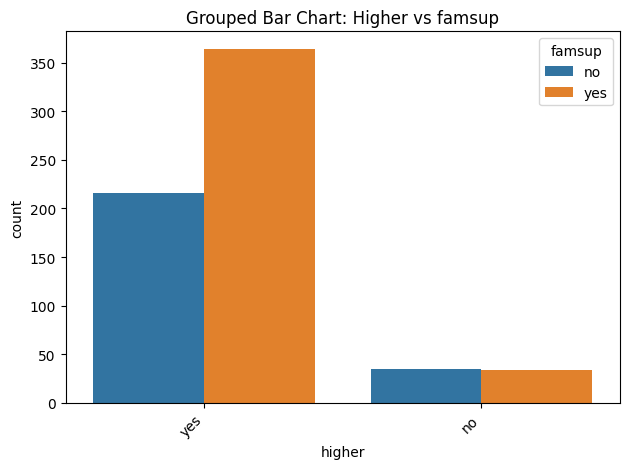

paid     no  yes
higher          
no       66    3
yes     544   36
Fisher's Exact Test: p-value = 0.7882


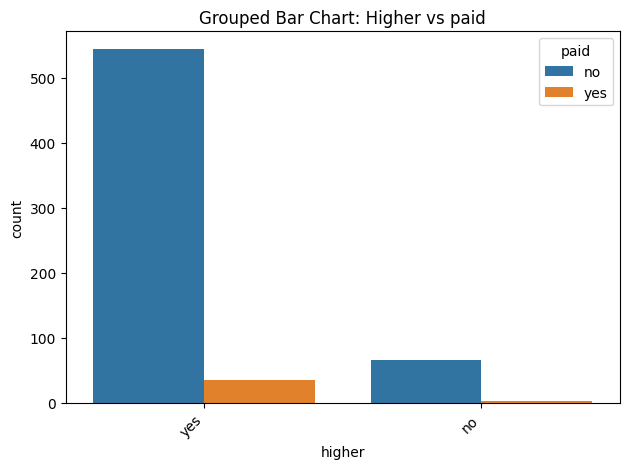

activities   no  yes
higher              
no           40   29
yes         294  286
Fisher's Exact Test: p-value = 0.3081


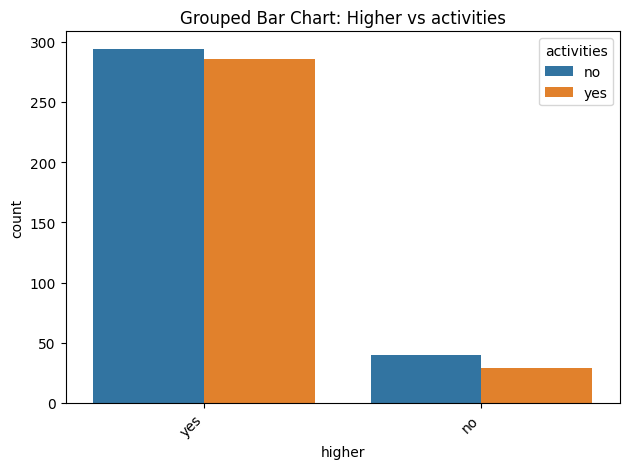

nursery   no  yes
higher           
no        17   52
yes      111  469
Fisher's Exact Test: p-value = 0.2667


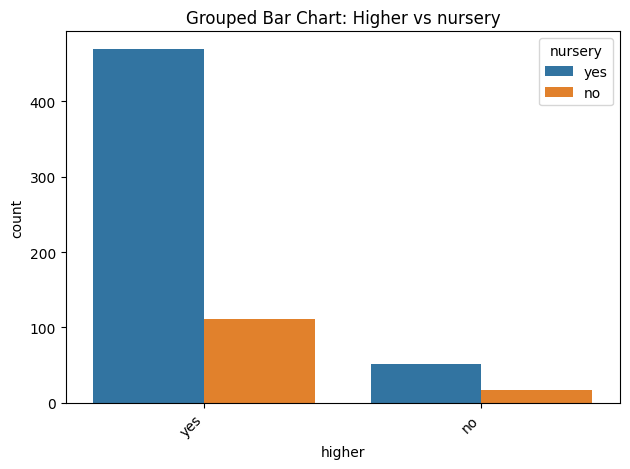

school   GP   MS
higher          
no       32   37
yes     391  189
Fisher's Exact Test: p-value = 0.0008


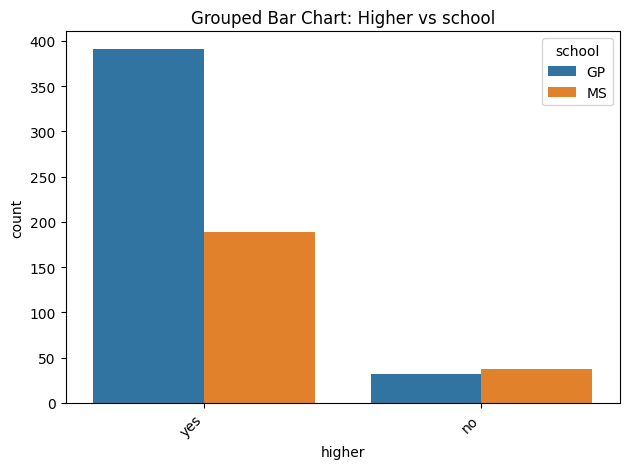

romantic   no  yes
higher            
no         34   35
yes       376  204
Fisher's Exact Test: p-value = 0.0169


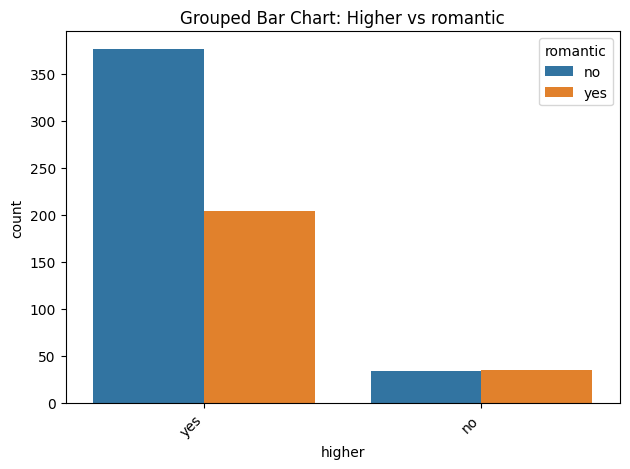

famrel   1   2   3    4    5
higher                      
no       5   3  12   30   19
yes     17  26  89  287  161
G-Test: G = 3.2877, p-value = 0.5109


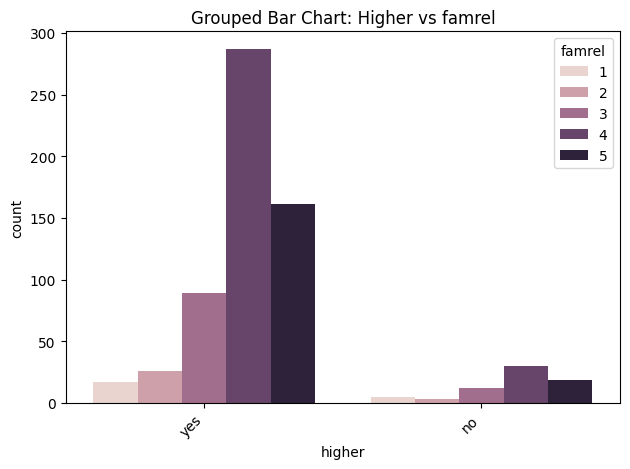

freetime   1   2    3    4   5
higher                        
no         4   9   20   21  15
yes       41  98  231  157  53
G-Test: G = 10.4188, p-value = 0.0339


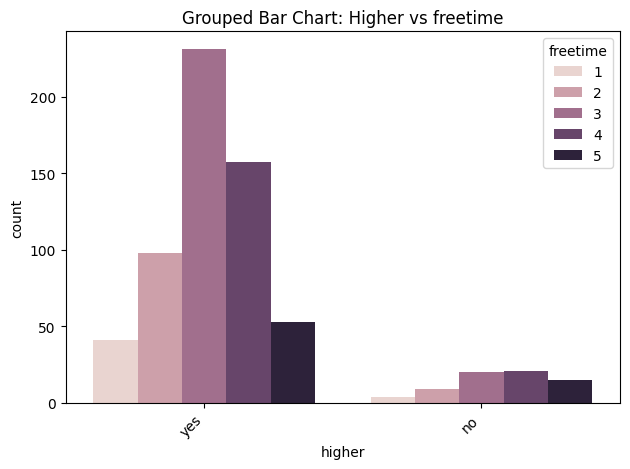

goout    1    2    3    4   5
higher                       
no       8    9   19   12  21
yes     40  136  186  129  89
Chi-Square Test: chi2 = 14.1810, p-value = 0.0067


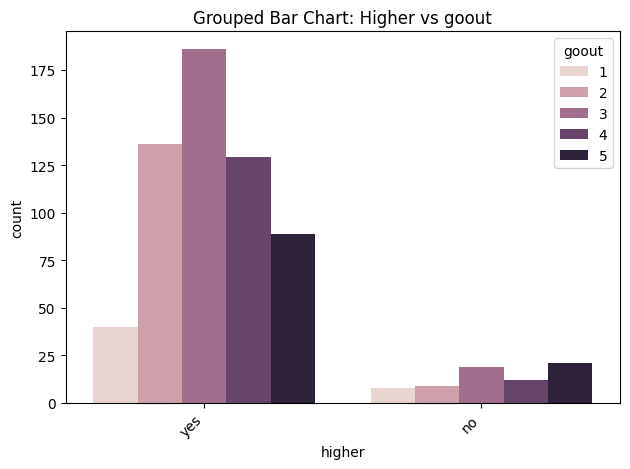

Dalc      1    2   3   4   5
higher                      
no       37   18   6   3   5
yes     414  103  37  14  12
G-Test: G = 10.8048, p-value = 0.0288


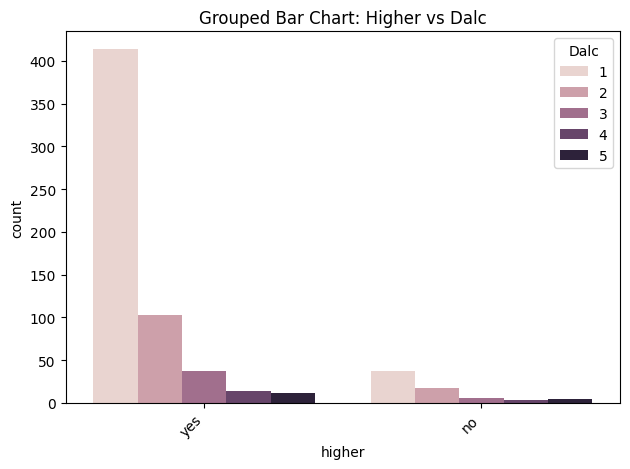

Walc      1    2    3   4   5
higher                       
no       22   13   14  11   9
yes     225  137  106  76  36
G-Test: G = 5.3441, p-value = 0.2538


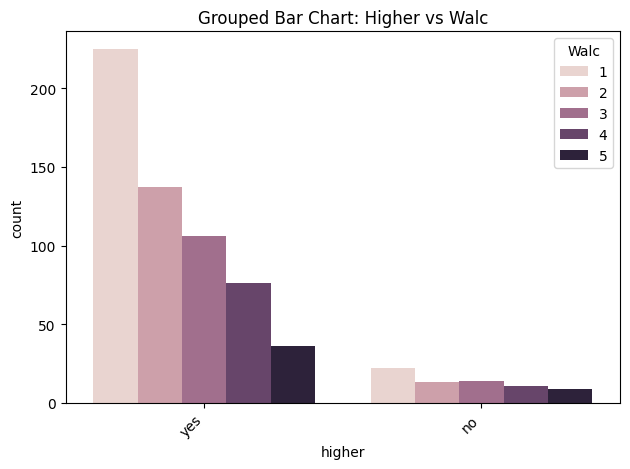

health   1   2    3   4    5
higher                      
no       9   9   14  15   22
yes     81  69  110  93  227
Chi-Square Test: chi2 = 2.2135, p-value = 0.6966


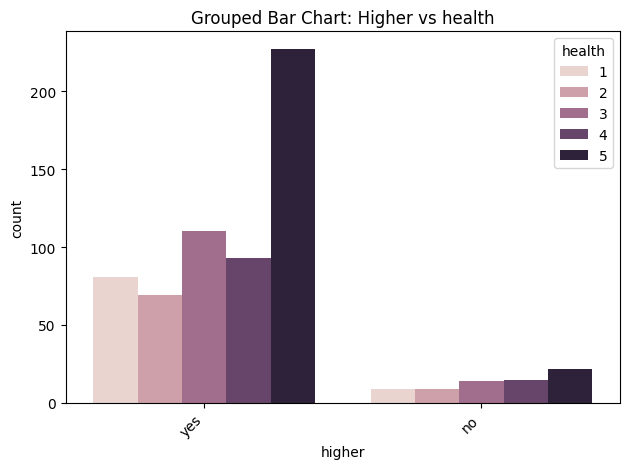

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import Table

variables_to_test = ['address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'school', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
alpha = 0.05

# Iteration through variables, providing chi-square test for each of them
for variable in variables_to_test:
    # Creating contingency table
    contingency_table = pd.crosstab(data_filt_abs['higher'], data_filt_abs[variable])
    print(contingency_table)

    if contingency_table.shape == (2, 2):
        # Fisher's Exact Test for 2x2 tables
        oddsratio, p = fisher_exact(contingency_table)
        print(f"Fisher's Exact Test: p-value = {p:.4f}")
    else:
        # Perform Chi-Square Test with automatic handling for expected frequencies
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        if np.any(expected < 5):
            # Use G-Test if expected frequencies are too low
            g, p_g, _, _ = chi2_contingency(contingency_table, lambda_="log-likelihood")
            print(f"G-Test: G = {g:.4f}, p-value = {p_g:.4f}")
        else:
            print(f"Chi-Square Test: chi2 = {chi2:.4f}, p-value = {p:.4f}")

    # if p < alpha:
        # Create grouped bar chart
    sns.countplot(x='higher', hue=variable, data=data_filt_abs)
    plt.title(f"Grouped Bar Chart: Higher vs {variable}")
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
    plt.tight_layout()
    plt.show()


# Predikce skóre ve 3. ročníku

In [23]:
import statsmodels.formula.api as smf


# Create dummy variables for categorical features
data_with_dummies = pd.get_dummies(
    data_filt_abs, columns=['higher', 'school', 'Medu', 'Fedu'], drop_first=True
)

# Define the formula for the linear regression model, including dummy variables for Medu and Fedu
formula = 'G3 ~ G1 + G2 + failures + higher_yes + school_MS + ' \
          'Medu_1 + Medu_2 + Medu_3 + Medu_4 + ' \
          'Fedu_1 + Fedu_2 + Fedu_3 + Fedu_4'

# Fit the model
model = smf.ols(formula, data=data_with_dummies).fit()

# Print the equation
print("Equation:")
print(f"G3 = {model.params['Intercept']:.2f}", end=" ")
for name, coef in model.params.items():
    if name != 'Intercept':
        print(f"+ {coef:.2f}*{name}", end=" ")
print()

# Print the model summary
print(model.summary())


Equation:
G3 = 0.60 + 0.16*higher_yes[T.True] + -0.23*school_MS[T.True] + -0.16*Medu_1[T.True] + -0.20*Medu_2[T.True] + -0.22*Medu_3[T.True] + -0.35*Medu_4[T.True] + -0.27*Fedu_1[T.True] + -0.19*Fedu_2[T.True] + -0.18*Fedu_3[T.True] + -0.20*Fedu_4[T.True] + 0.13*G1 + 0.89*G2 + -0.20*failures 
                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     278.2
Date:                Mon, 09 Dec 2024   Prob (F-statistic):          5.83e-252
Time:                        15:46:42   Log-Likelihood:                -1064.5
No. Observations:                 649   AIC:                             2157.
Df Residuals:                     635   BIC:                             2220.
Df Model:                          13                                     

In [ ]:
data_with_dummies

,address,famsize,Pstatus,traveltime,studytime,failures,schoolsup,famsup,paid,activities,...,higher_yes,school_MS,Medu_1,Medu_2,Medu_3,Medu_4,Fedu_1,Fedu_2,Fedu_3,Fedu_4
0,U,GT3,A,2,2,0,yes,no,no,no,...,True,False,False,False,False,True,False,False,False,True
1,U,GT3,T,1,2,0,no,yes,no,no,...,True,False,True,False,False,False,True,False,False,False
2,U,LE3,T,1,2,0,yes,no,no,no,...,True,False,True,False,False,False,True,False,False,False
3,U,GT3,T,1,3,0,no,yes,no,yes,...,True,False,False,False,False,True,False,True,False,False
4,U,GT3,T,1,2,0,no,yes,no,no,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,R,GT3,T,1,3,1,no,no,no,yes,...,True,True,False,True,False,False,False,False,True,False
645,U,LE3,T,1,2,0,no,yes,no,no,...,True,True,False,False,True,False,True,False,False,False
646,U,GT3,T,2,2,0,no,no,no,yes,...,True,True,True,False,False,False,True,False,False,False
647,U,LE3,T,2,1,0,no,no,no,no,...,True,True,False,False,True,False,True,False,False,False


In [28]:
print(data_with_dummies.iloc[4, :])

address                U
famsize              GT3
Pstatus                T
traveltime             1
studytime              2
failures               0
schoolsup             no
famsup               yes
paid                  no
activities            no
nursery              yes
romantic              no
famrel                 4
freetime               3
goout                  2
Dalc                   1
Walc                   2
health                 5
G1                    11
G2                    13
G3                    13
failures_binary        0
higher_yes          True
school_MS          False
Medu_1             False
Medu_2             False
Medu_3              True
Medu_4             False
Fedu_1             False
Fedu_2             False
Fedu_3              True
Fedu_4             False
Name: 4, dtype: object
